In [ ]:
%pip install gdstk

### 库函数调用

In [27]:
import gdstk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import QD_Layout_Gen_v1 as QD_Gen

import datetime

now = datetime.datetime.now()
year = now.year
month = now.month
day = now.day

time = str(year)+str(month)+str(day)

### Generate Device Layout

GDS 文件已更新并保存为: '6qd_device_with_labels_unified_sets_20251212.gds'
Auto-adjusting View: X[-0.34, 1.44], Y[-0.46, 0.82]


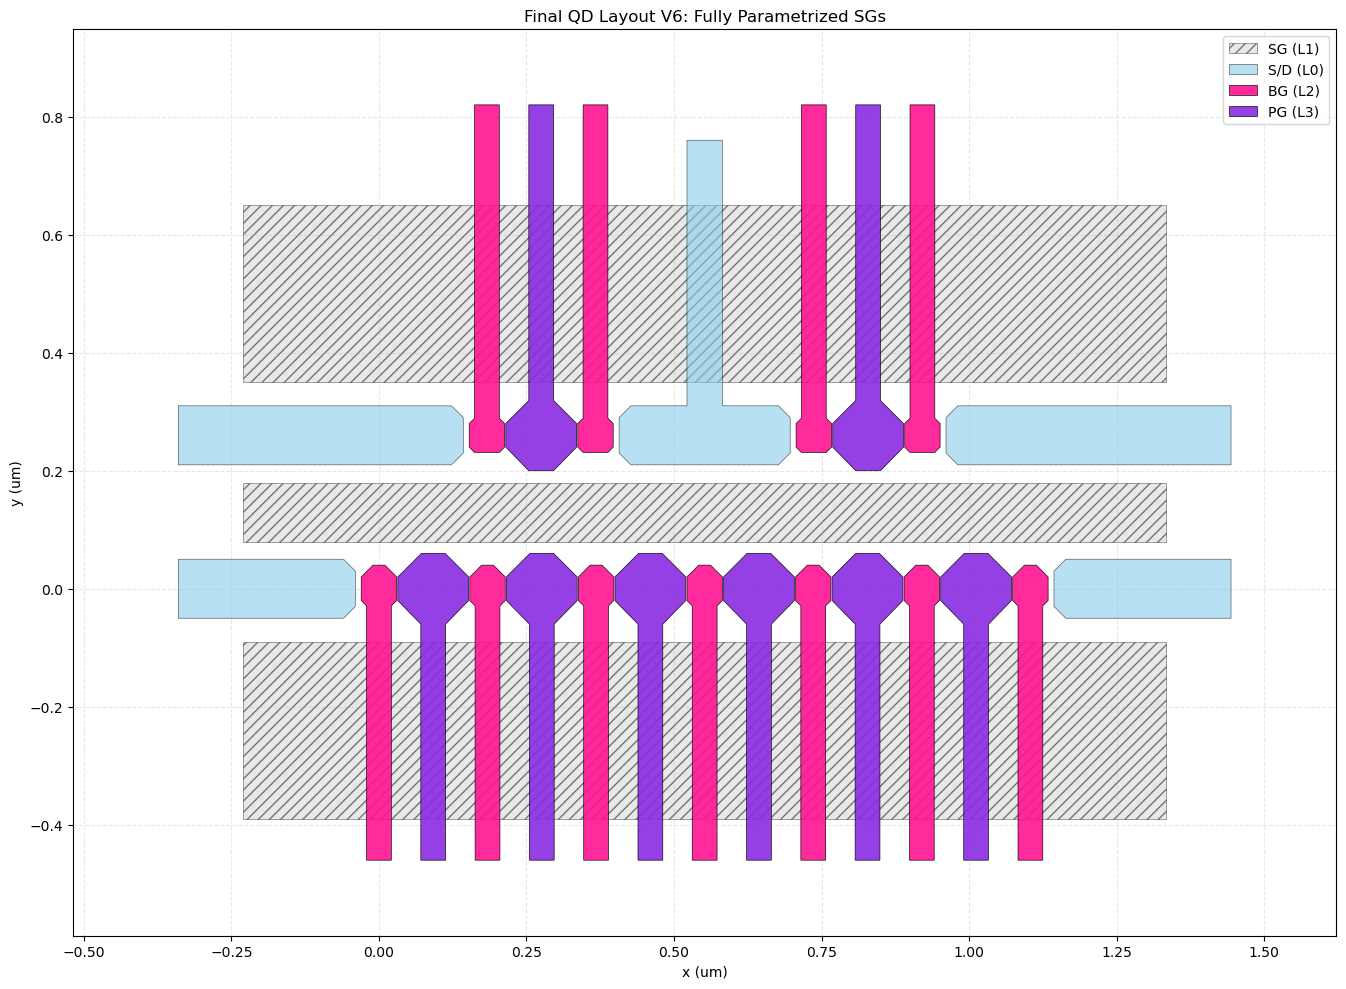

In [ ]:
# --- 参数定义 ---
pg_max_width=0.120; pg_vert_side_len=0.040; pg_chamfer_h=0.040; pg_bot_flat_w=0.042; pg_top_flat_w=0.040
bg_max_width=0.060; bg_vert_side_len=0.040; bg_top_flat_w=0.020; bg_bot_flat_w=0.042
gap_pg_bg=0.002; d1_gap=0.020; d2_gap=0.020; sd_gap_to_gate=0.01; gap_gate_outer_sg=0.030
sg_mid_thick=0.100; sg_top_thick=0.300; sg_bot_thick=0.300; sg_extension=0.200
lead_width=0.042; lead_length_bot=0.4; lead_length_top=0.5; lead_overlap=0.025
sd_height=0.10; sd_width=0.35; sd_lead_width=0.060; sd_outer_length=0.300
    
    # --- 调用函数生成布局 ---
lib, cell = QD_Gen.create_6qd_layout_with_labels(
    pg_max_width, pg_vert_side_len, pg_chamfer_h, pg_bot_flat_w, pg_top_flat_w,
    bg_max_width, bg_vert_side_len, bg_top_flat_w, bg_bot_flat_w,
    gap_pg_bg, d1_gap, d2_gap, sd_gap_to_gate, gap_gate_outer_sg,
    sg_mid_thick, sg_top_thick, sg_bot_thick, sg_extension,
    lead_width, lead_length_bot, lead_length_top, lead_overlap,
    sd_height, sd_width, sd_lead_width, sd_outer_length
)
    
output_filename = '6qd_device_with_labels_unified_sets_' + time + '.gds'
lib.write_gds(output_filename)
print(f"GDS 文件已更新并保存为: '{output_filename}'")
QD_Gen.plot_gds(cell)

### Generate Quantum Dot Pad Layout

Pad Distribution: Left=['SG1', 'SET1_D', 'SG2', 'QD_D', 'QD_B1', 'QD_PG1', 'QD_B2'],
 Bottom=['QD_PG2', 'QD_B3', 'QD_PG3', 'QD_B4', 'QD_PG4', 'QD_B5', 'QD_PG5', 'QD_B6'],
 Right=['SET2_D', 'QD_S', 'GND', 'SG3', 'GND', 'QD_B7', 'QD_PG6'],
 Top=['SET1_B1', 'SET1_B2', 'SET1_G', 'SET_S', 'SET2_G', 'SET2_B2', 'SET2_B1']
GDS file saved to: QD_Prefab_layout_20251212.gds


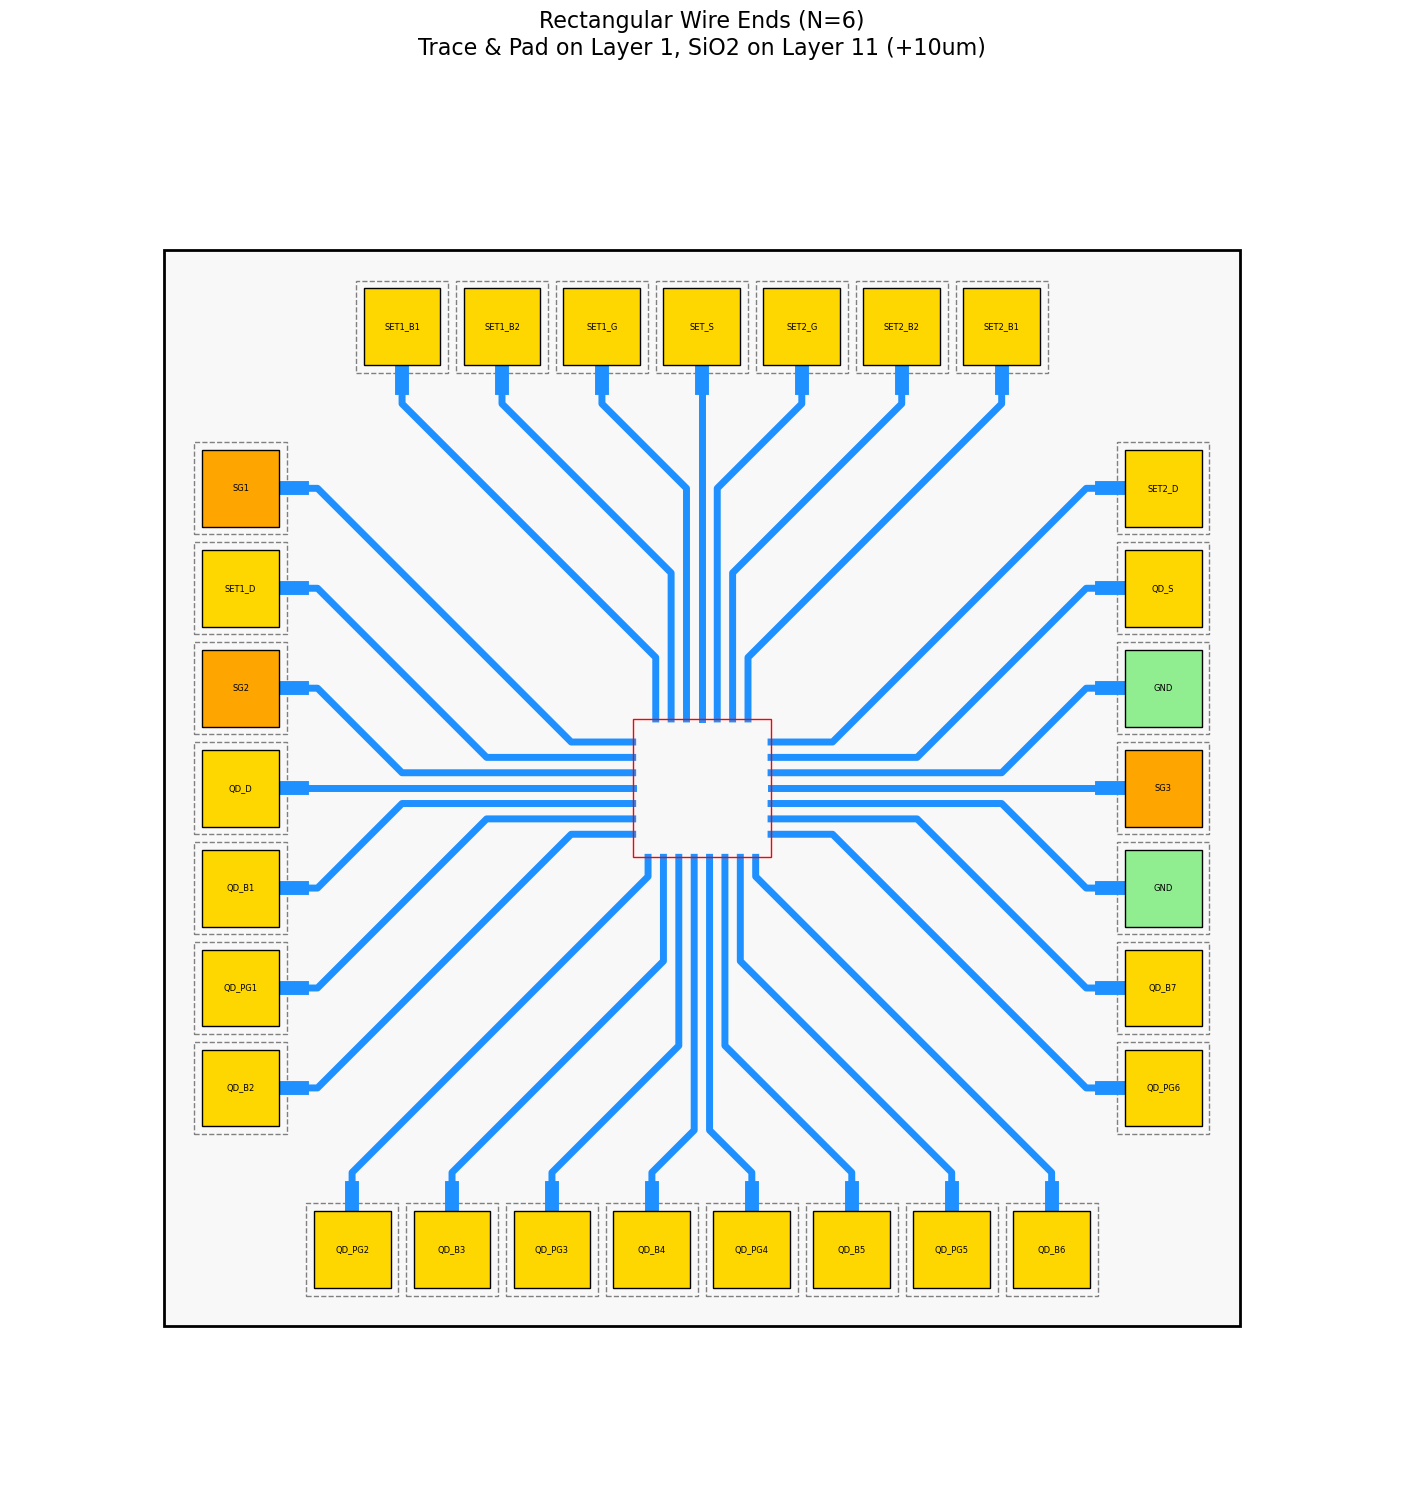

In [29]:
if __name__ == '__main__':
    QD_Gen.create_rect_wire_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 50,
        active_size = 180,     
        trace_width = 10,    # [设置] 10um 导线宽度
        trace_spacing = 10,
        taper_length = 30,
        active_entry_len = 20,
        gds_filename='QD_Prefab_layout_' + time + '.gds'
    )

### Generate Interconnects between Electrodes and Pads

# Test


Auto-adjusting View: X[-0.34, 1.44], Y[-0.46, 0.82]


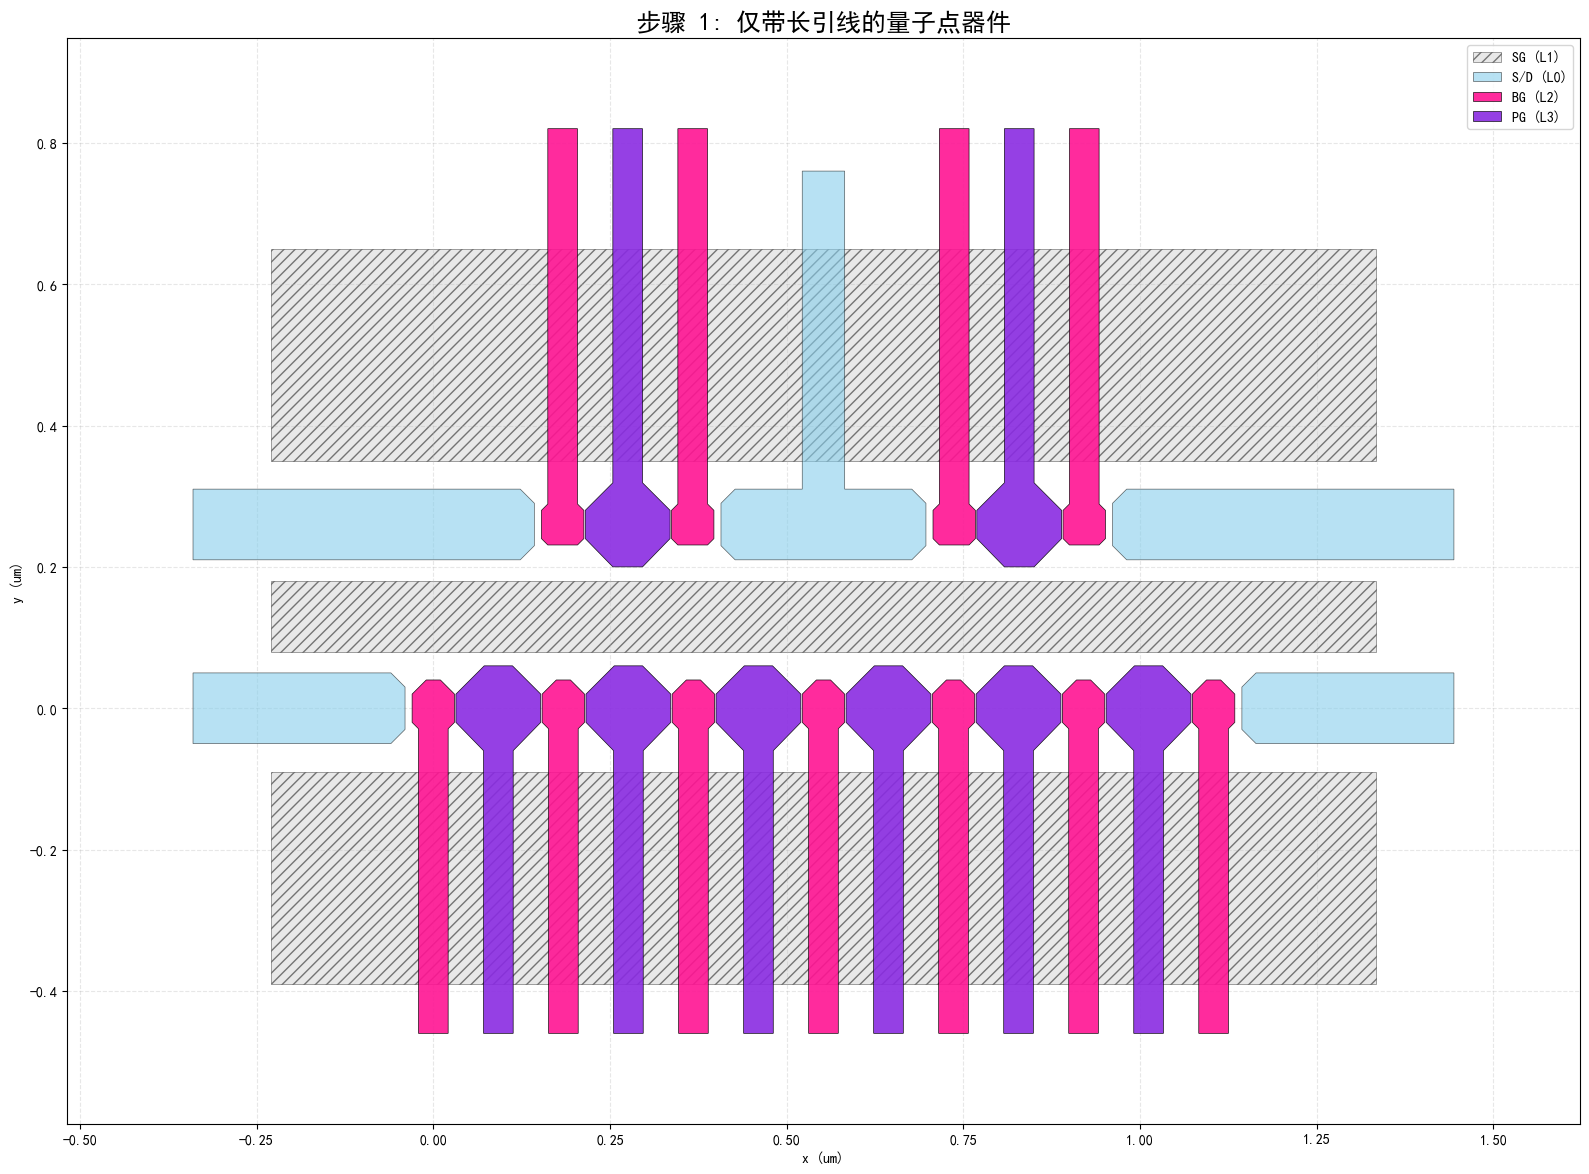

GDS 文件已保存到: 'step1_device_with_leads.gds'

--- 步骤 2: 仅带引线的焊盘框架 ---
正在可视化: 步骤 2: 仅带引线的焊盘框架...


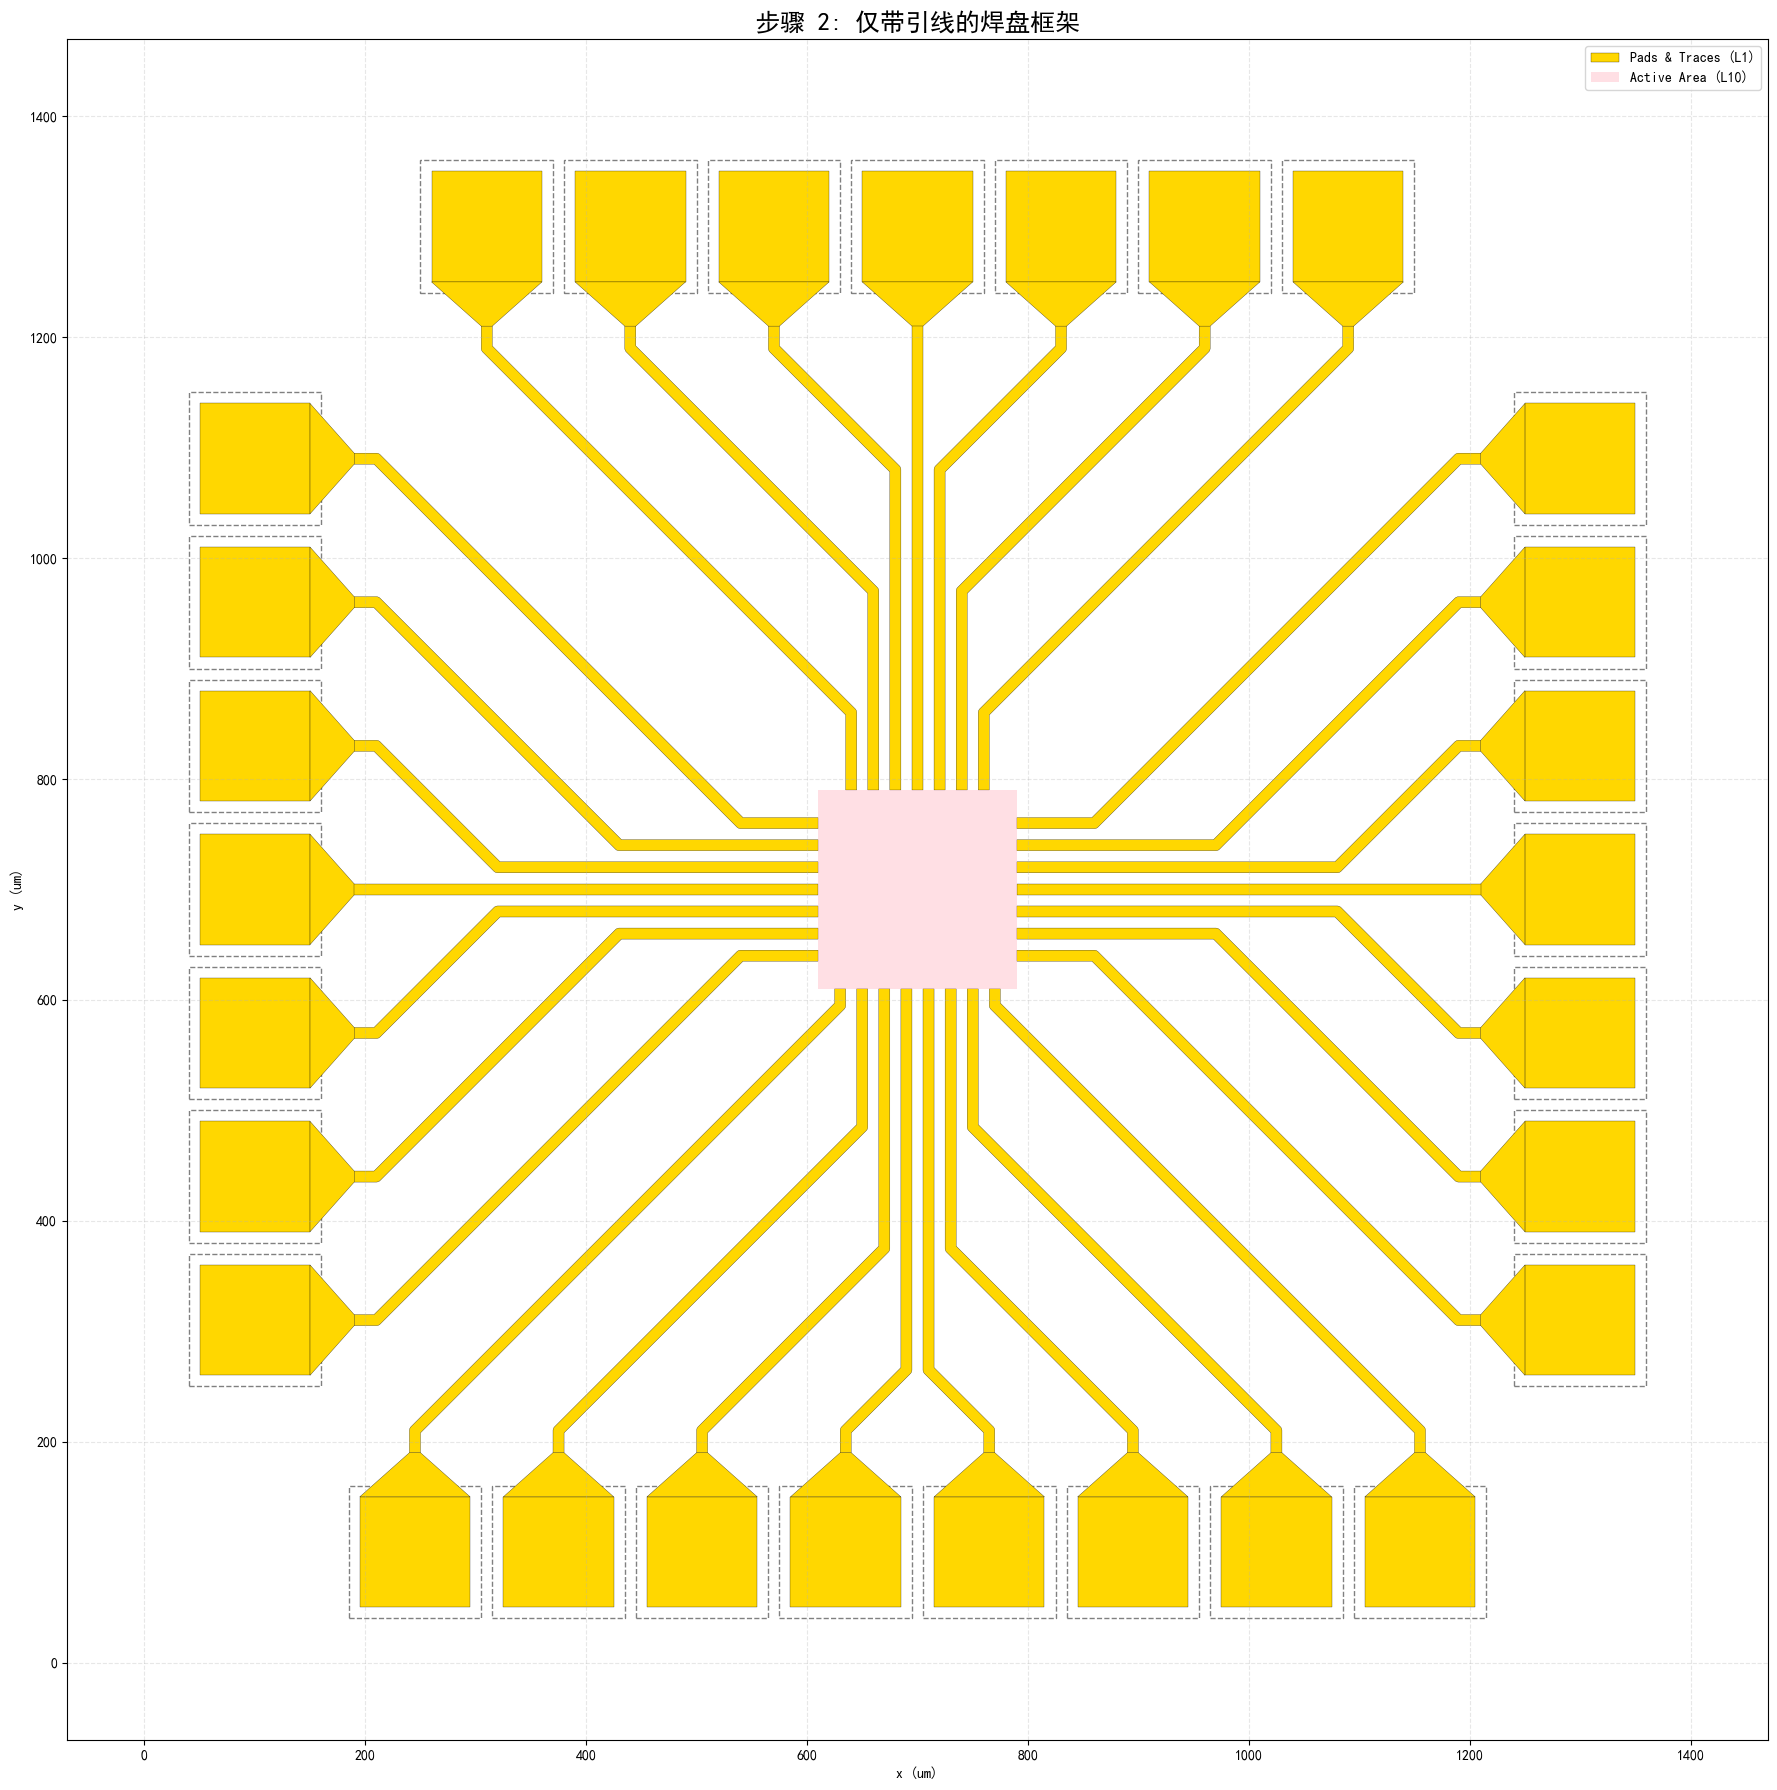

GDS 文件已保存到: 'step2_pad_frame.gds'

--- 步骤 3: 器件已放置 (未布线) ---
正在可视化: 步骤 3: 器件已放置 (未布线)...


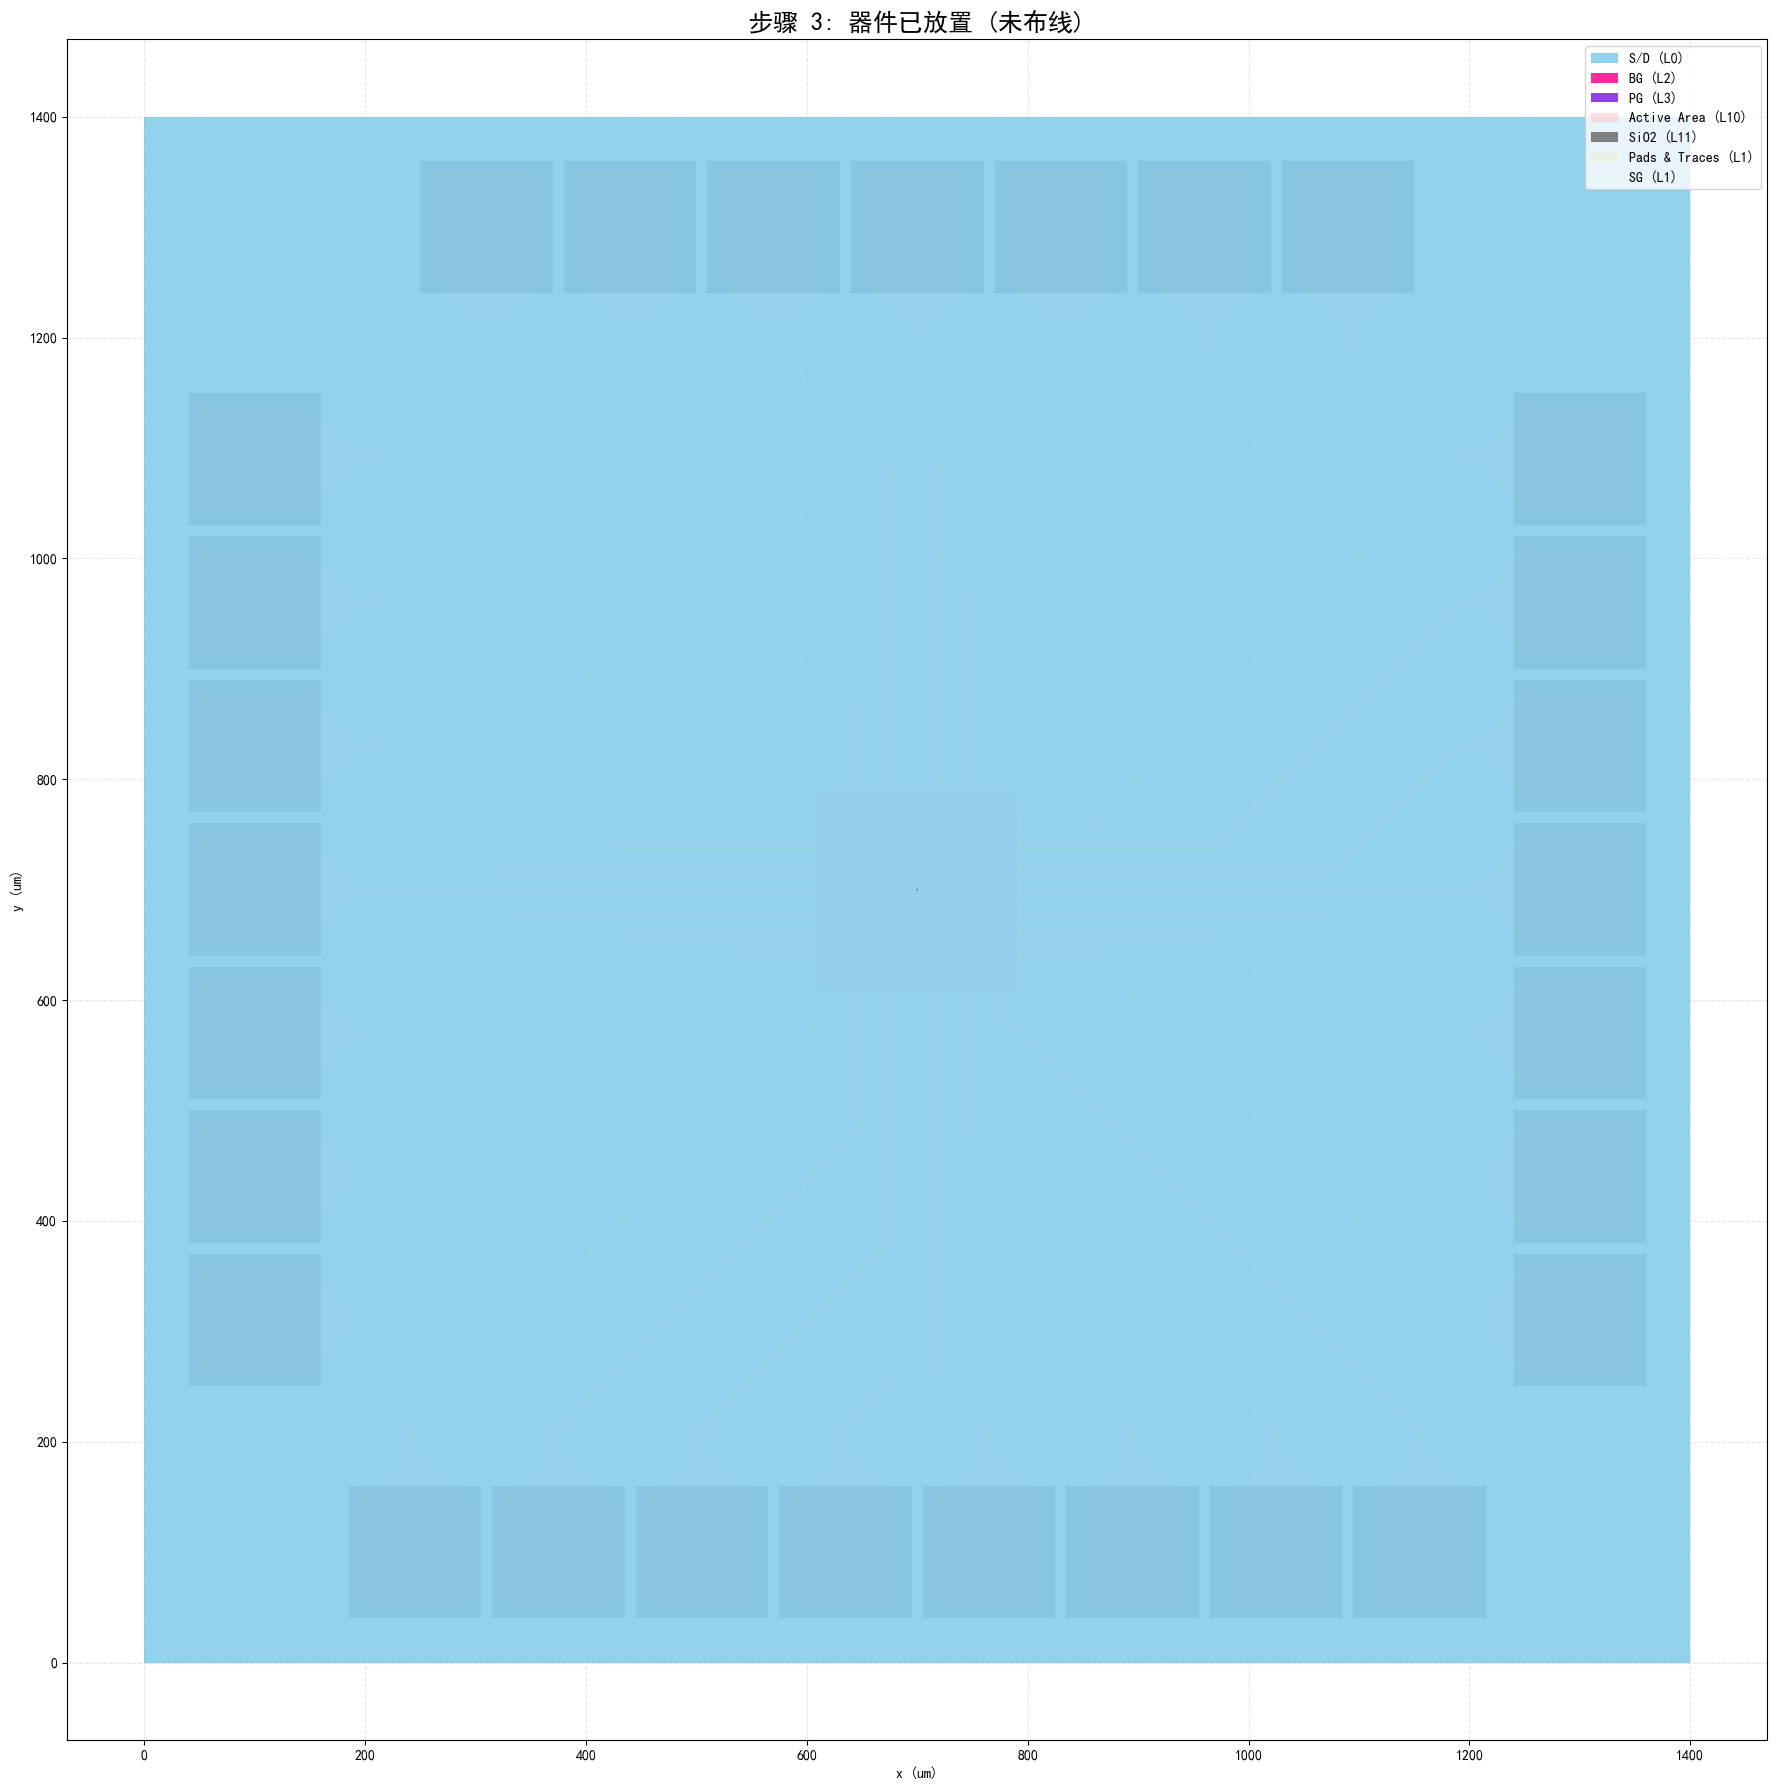

GDS 文件已保存到: 'step3_placed_unrouted.gds'

--- 步骤 4: 连接单条线 (QD_PG4) ---
正在可视化: 步骤 4: 连接单条线 (QD_PG4)...


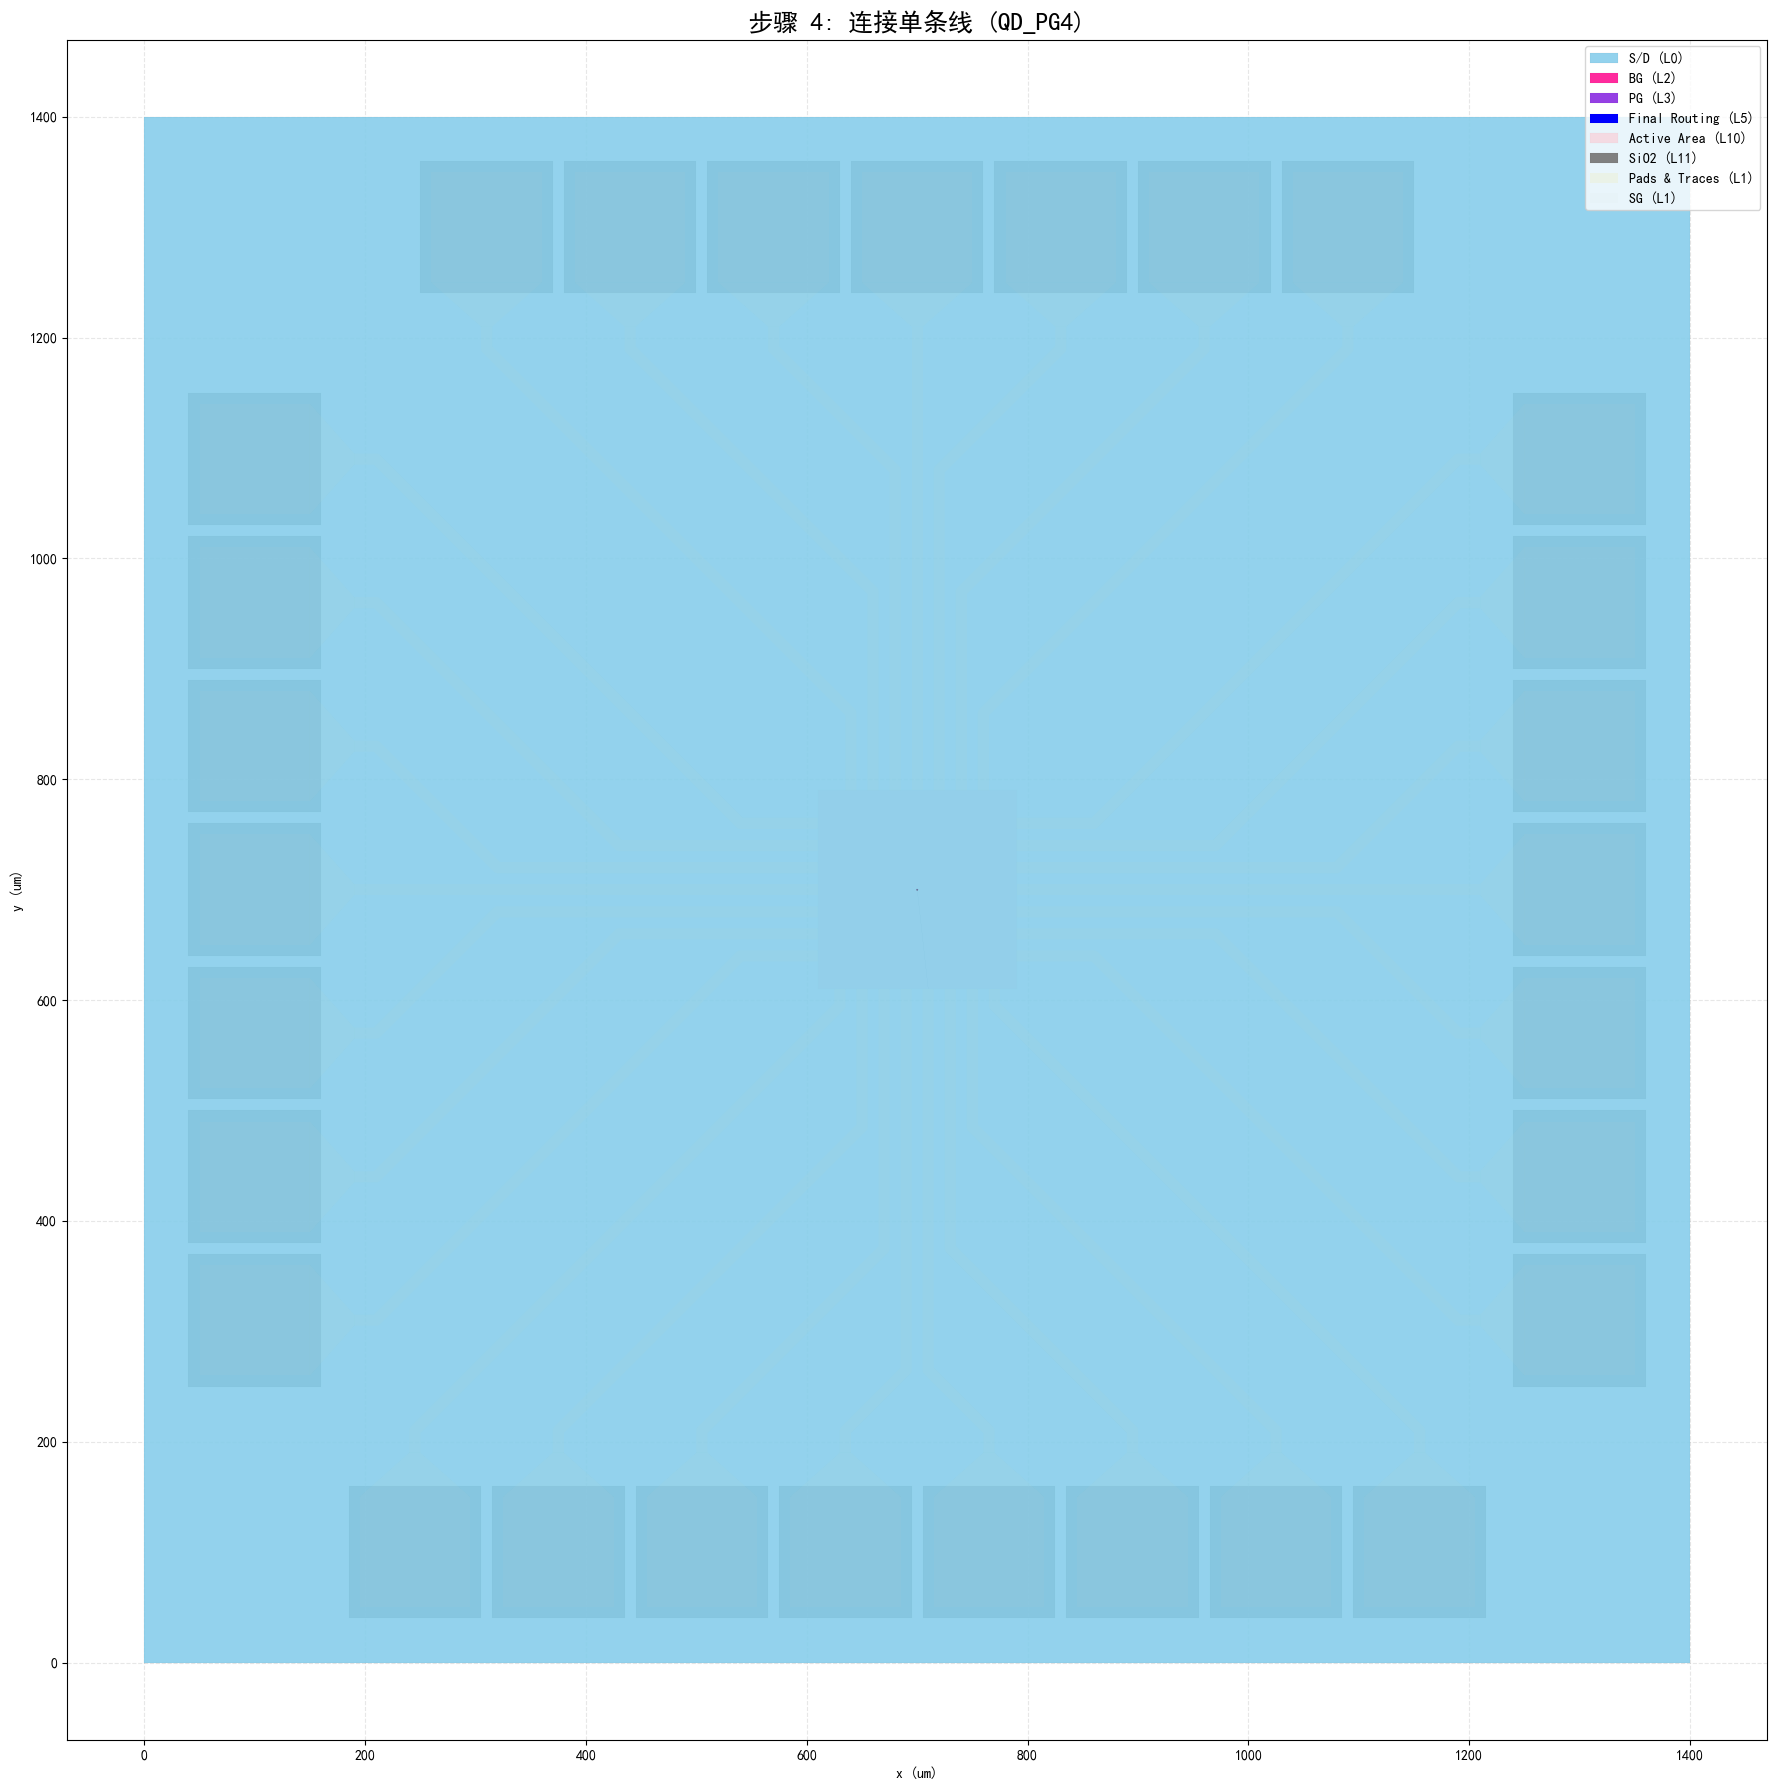

GDS 文件已保存到: 'step4_single_route.gds'

--- 步骤 5: 正在连接所有剩余的线... ---
--- 步骤 5: 最终完整布线 ---
正在可视化: 步骤 5: 最终完整布线...


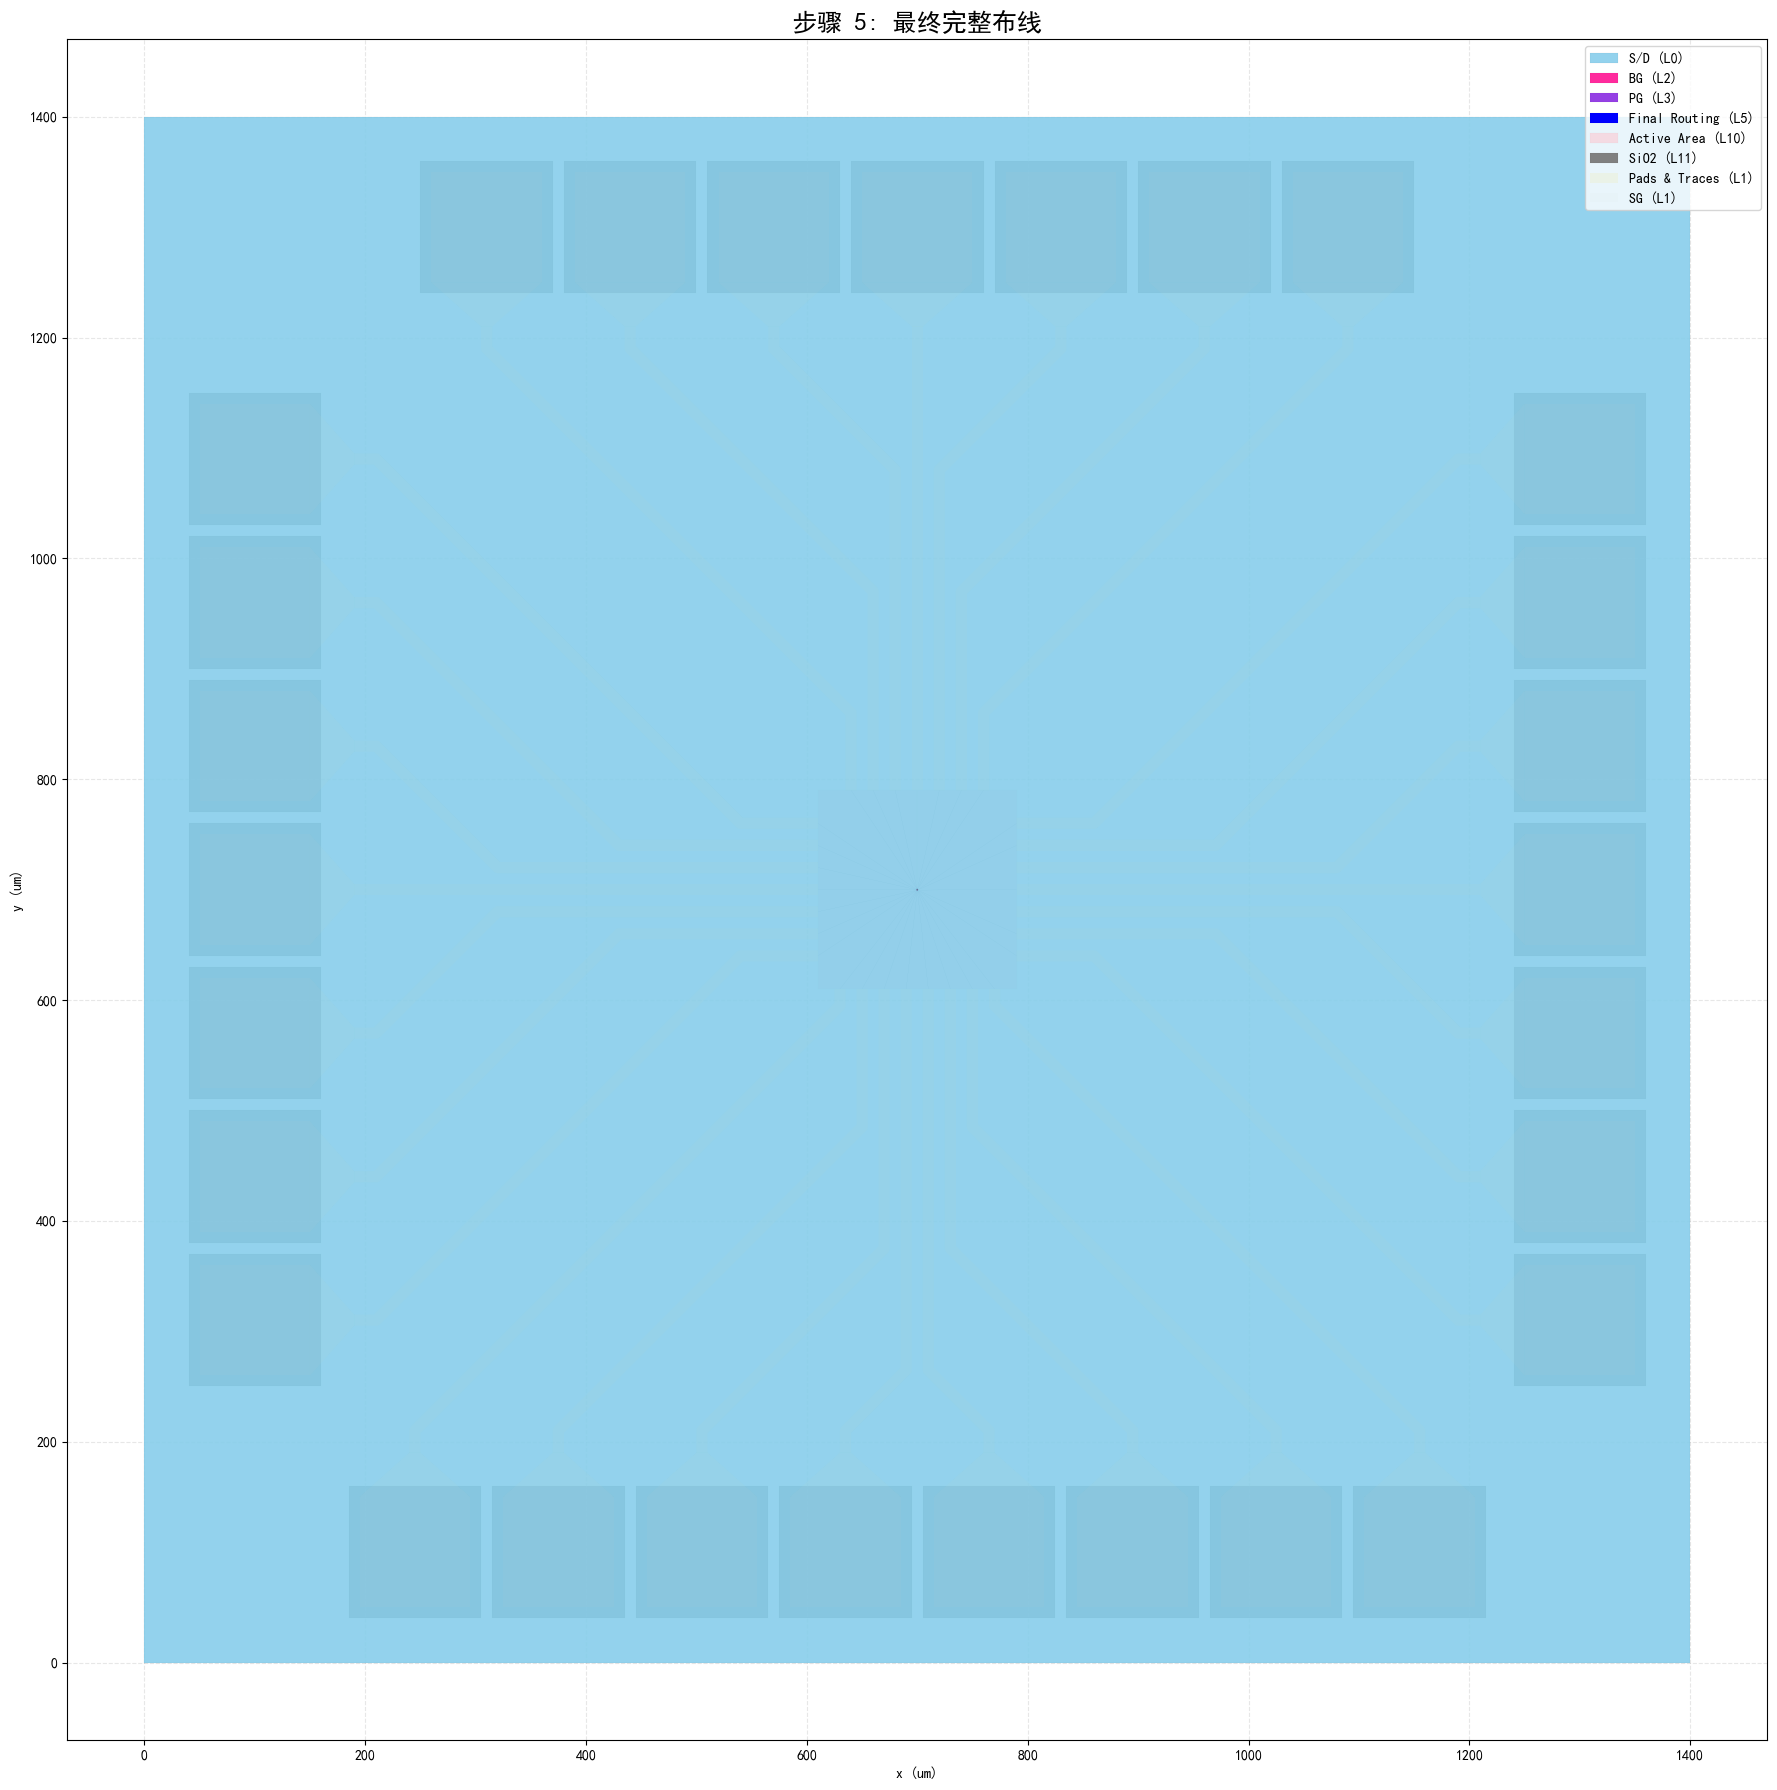

GDS 文件已保存到: 'step5_fully_routed.gds'

全部分步流程执行完毕！


In [2]:
import gdstk
import numpy as np

# 假设您的代码包文件名为 "my_layout_generators.py"
# 请根据您的实际文件名进行修改
%reload_ext autoreload
from QD_Layout_Gen_v2_20251215 import *

# ===================================================================
#                           主程序入口 (全新分步流程)
# ===================================================================
if __name__ == "__main__":

    # --- 步骤 1: 生成并展示核心器件 ---
    lib_device, cell_device, device_points = create_6qd_layout_with_labels()
    # 使用用户提供的 plot_gds 函数进行可视化
    plot_gds(cell_device, title="步骤 1: 仅带长引线的量子点器件")
    lib_device.write_gds("step1_device_with_leads.gds")
    print("GDS 文件已保存到: 'step1_device_with_leads.gds'\n")


    # --- 步骤 2: 生成并展示焊盘框架 ---
    lib_pads, cell_pads, pad_points, active_center = create_rect_wire_layout()
    visualize_and_save_pad_frame(lib_pads, cell_pads, 
                       "步骤 2: 仅带引线的焊盘框架", 
                       "step2_pad_frame.gds")

    # --- 步骤 3: 组装 - 将器件放置在中心 (未布线) ---
    # 居中器件，以便精确放置
    bbox = cell_device.bounding_box()
    if bbox:
        (min_x, min_y), (max_x, max_y) = bbox
        cx, cy = (min_x+max_x)/2, (min_y+max_y)/2
        # 平移几何对象
        for poly in cell_device.polygons: poly.translate(-cx, -cy)
        # 更新连接点坐标
        for label, pos in device_points.items(): device_points[label] = (pos[0]-cx, pos[1]-cy)
    
    assembly_lib = gdstk.Library(); assembly_cell = assembly_lib.new_cell('ASSEMBLY_CELL')
    assembly_cell.add(gdstk.Reference(cell_pads))
    device_ref = gdstk.Reference(cell_device, active_center)
    assembly_cell.add(device_ref)
    
    visualize_and_save_assembly(assembly_lib, assembly_cell, 
                       "步骤 3: 器件已放置 (未布线)", 
                       "step3_placed_unrouted.gds")

    # --- 步骤 4: 连接单条线进行演示 ---
    # 这里的逻辑是连接两个长引线的末端，所以最终连线会非常短
    label_to_connect = 'QD_PG4'
    if label_to_connect in device_points and label_to_connect in pad_points:
        pad_coord = pad_points[label_to_connect]
        local_dev_coord = device_points[label_to_connect]
        global_dev_coord = (local_dev_coord[0] + active_center[0], local_dev_coord[1] + active_center[1])
        
        path = gdstk.FlexPath(points=[pad_coord, global_dev_coord], width=0.03, layer=5, ends="flush")
        assembly_cell.add(path)

    visualize_and_save_assembly(assembly_lib, assembly_cell, 
                       f"步骤 4: 连接单条线 ({label_to_connect})", 
                       "step4_single_route.gds")

    # --- 步骤 5: 完成所有剩余的连接 ---
    print("--- 步骤 5: 正在连接所有剩余的线... ---")
    for label, local_dev_coord in device_points.items():
        if label != label_to_connect and label in pad_points:
            pad_coord = pad_points[label]
            global_dev_coord = (local_dev_coord[0] + active_center[0], local_dev_coord[1] + active_center[1])
            path = gdstk.FlexPath(points=[pad_coord, global_dev_coord], width=0.03, layer=5, ends="flush")
            assembly_cell.add(path)
            
    visualize_and_save_assembly(assembly_lib, assembly_cell, 
                       "步骤 5: 最终完整布线", 
                       "step5_fully_routed.gds")

    print("全部分步流程执行完毕！")


Auto-adjusting View: X[-0.34, 1.44], Y[-0.46, 0.82]


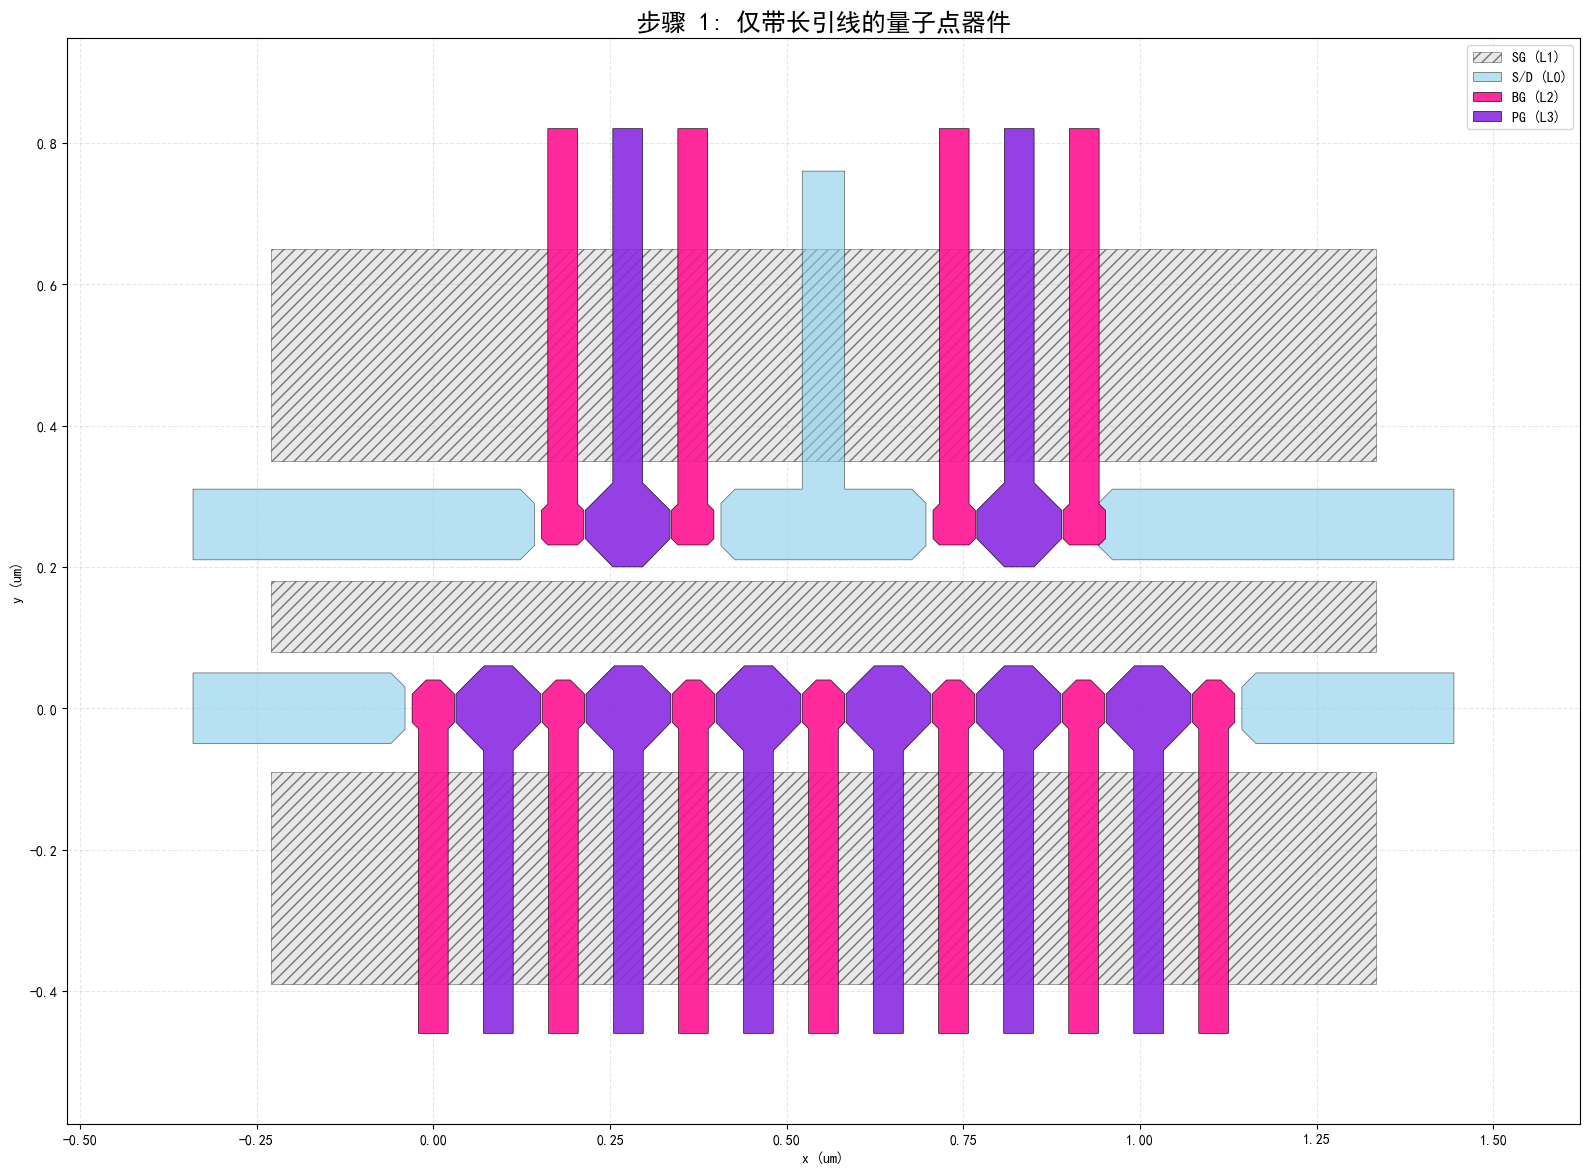

--- 步骤 2: 仅带引线的焊盘框架 ---
正在可视化: 步骤 2: 仅带引线的焊盘框架...


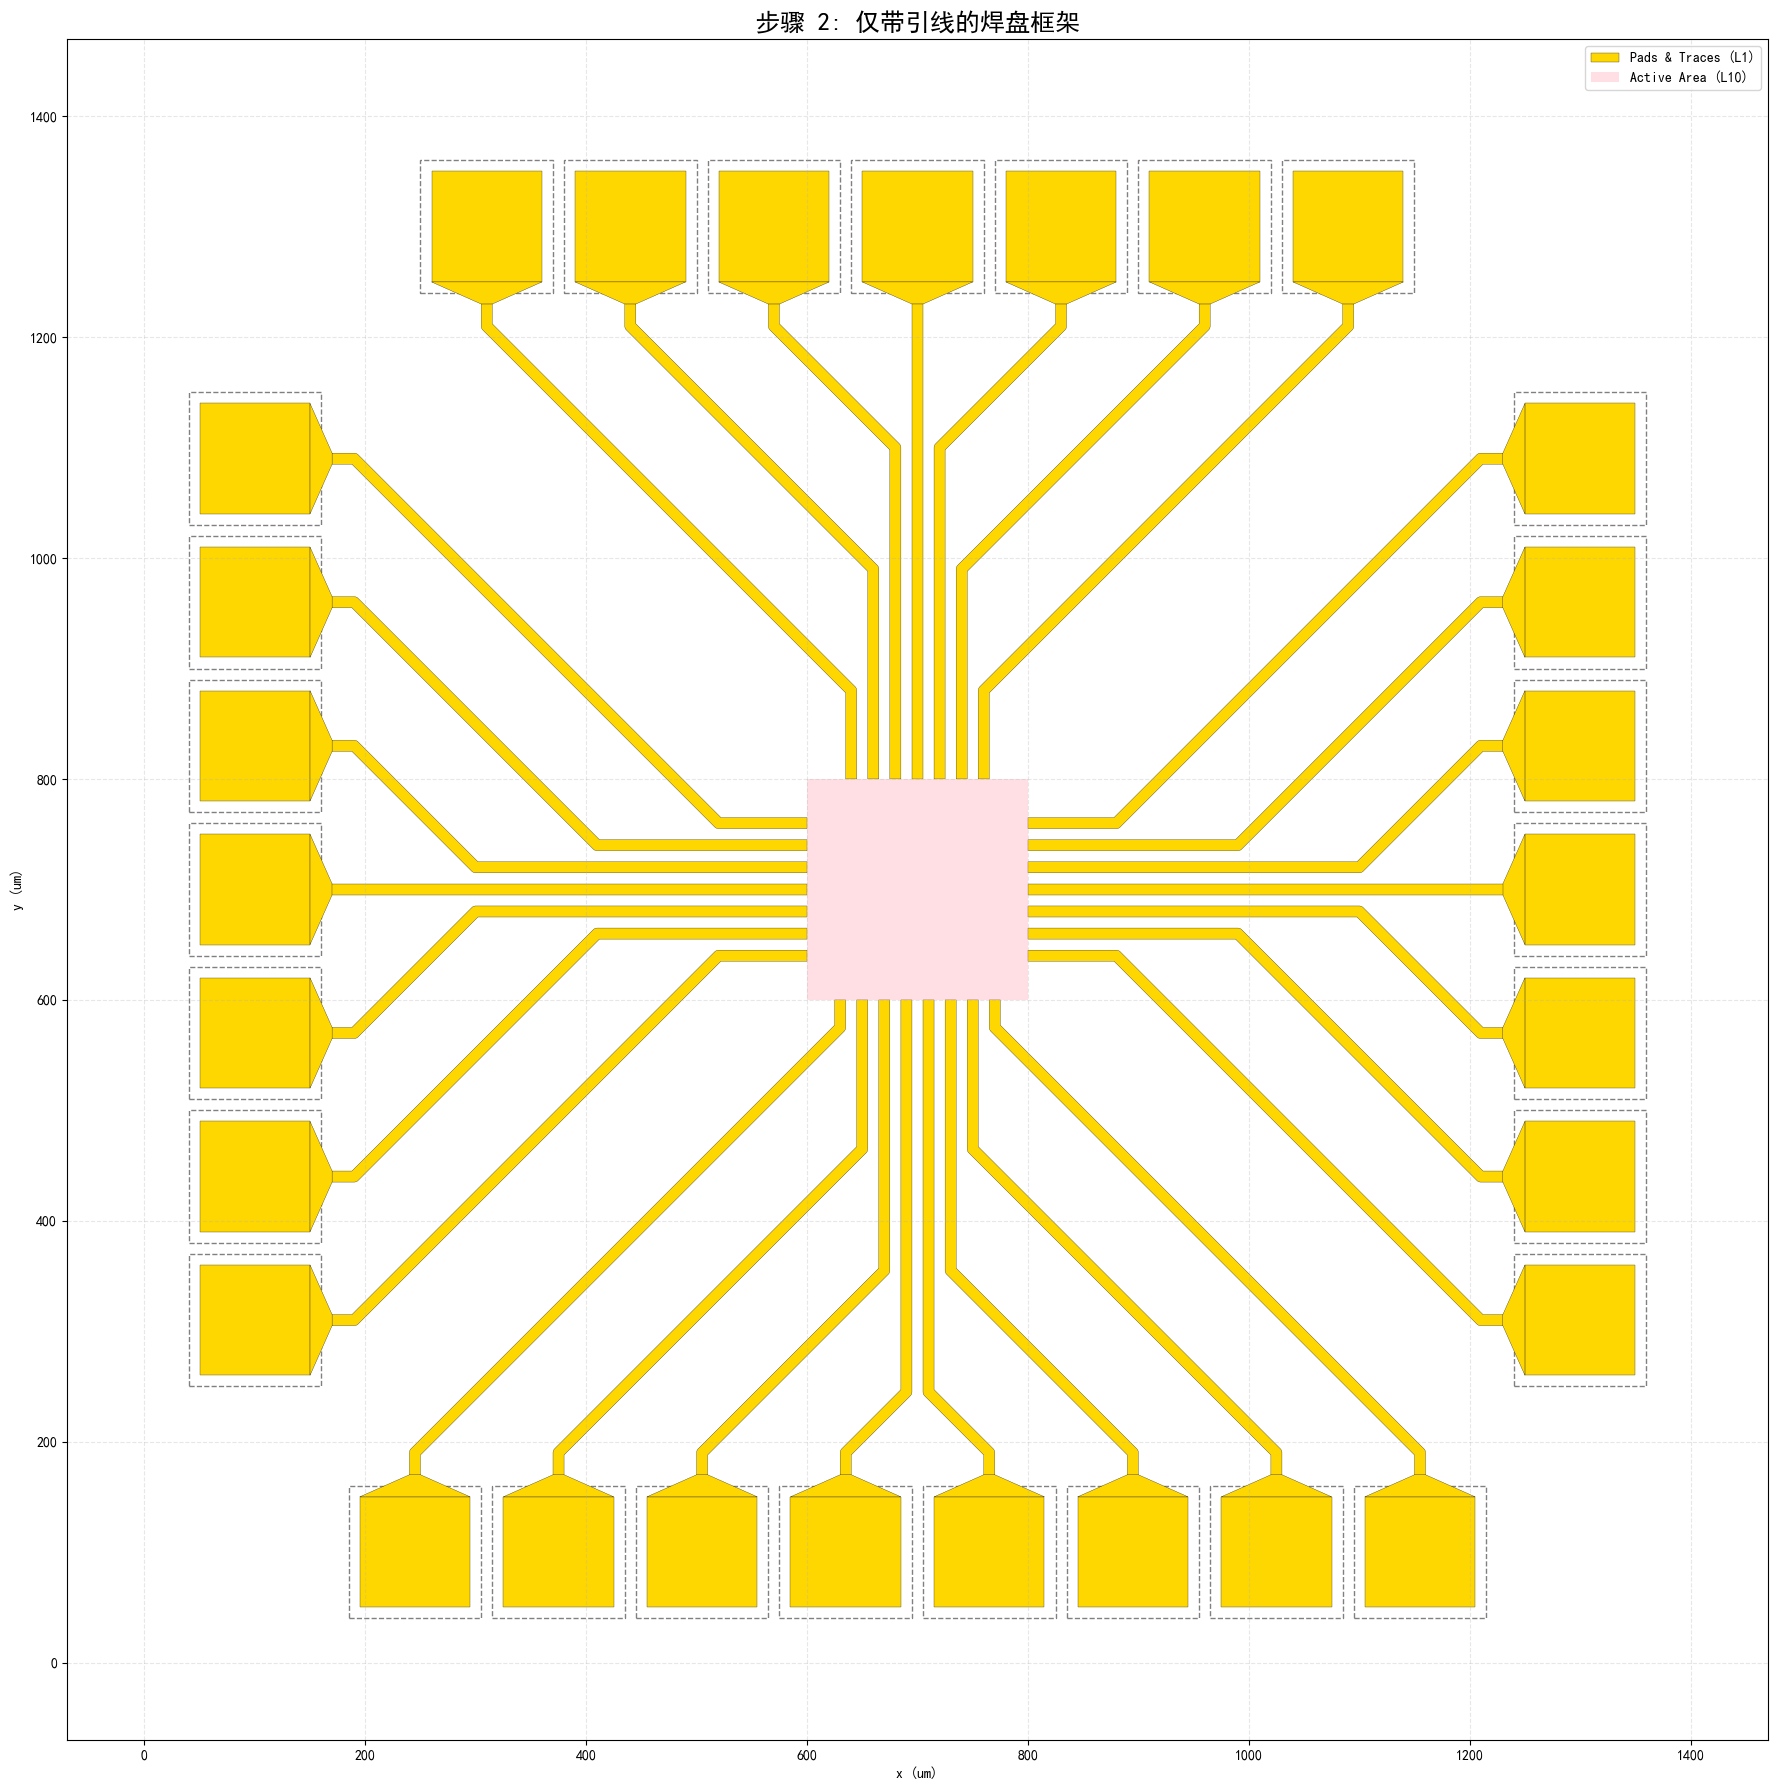

GDS 文件已保存到: 'step2_pad_frame.gds'

--- 步骤 3: 器件已放置 (未布线) ---
正在可视化: 步骤 3: 器件已放置 (未布线)...


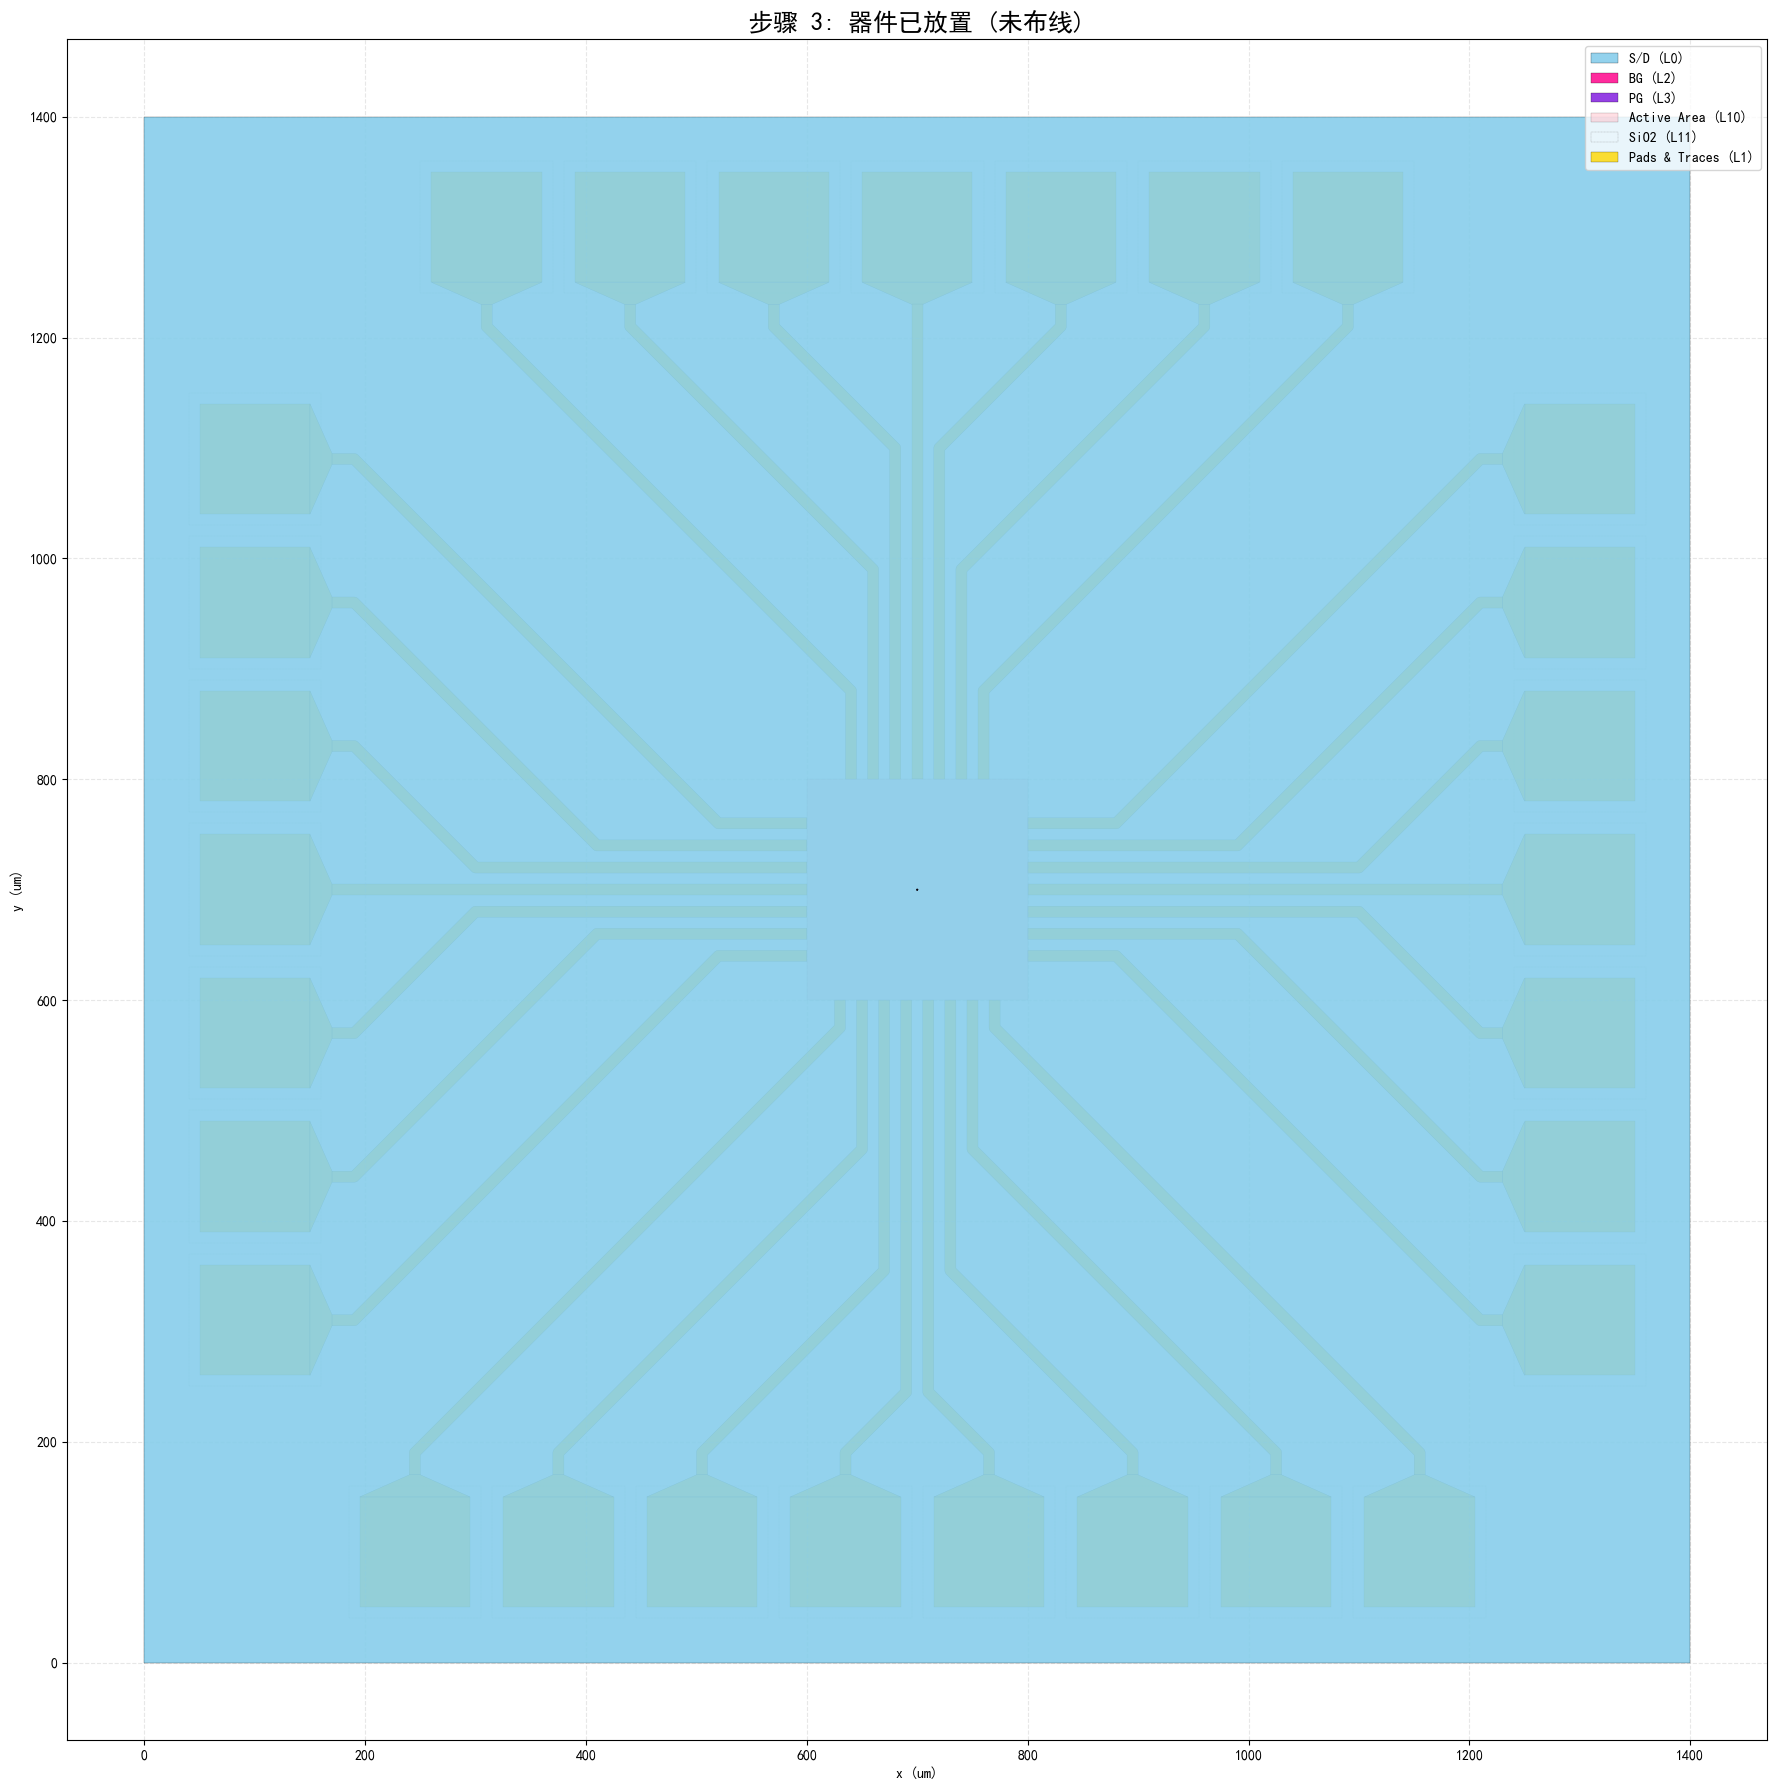

GDS 文件已保存到: 'step3_placed_unrouted.gds'

--- 步骤 4 & 5: 正在使用全新阶梯式 Fan-out 算法连接所有线... ---
--- 步骤 4: 连接单条线 (QD_PG4) ---
正在可视化: 步骤 4: 连接单条线 (QD_PG4)...


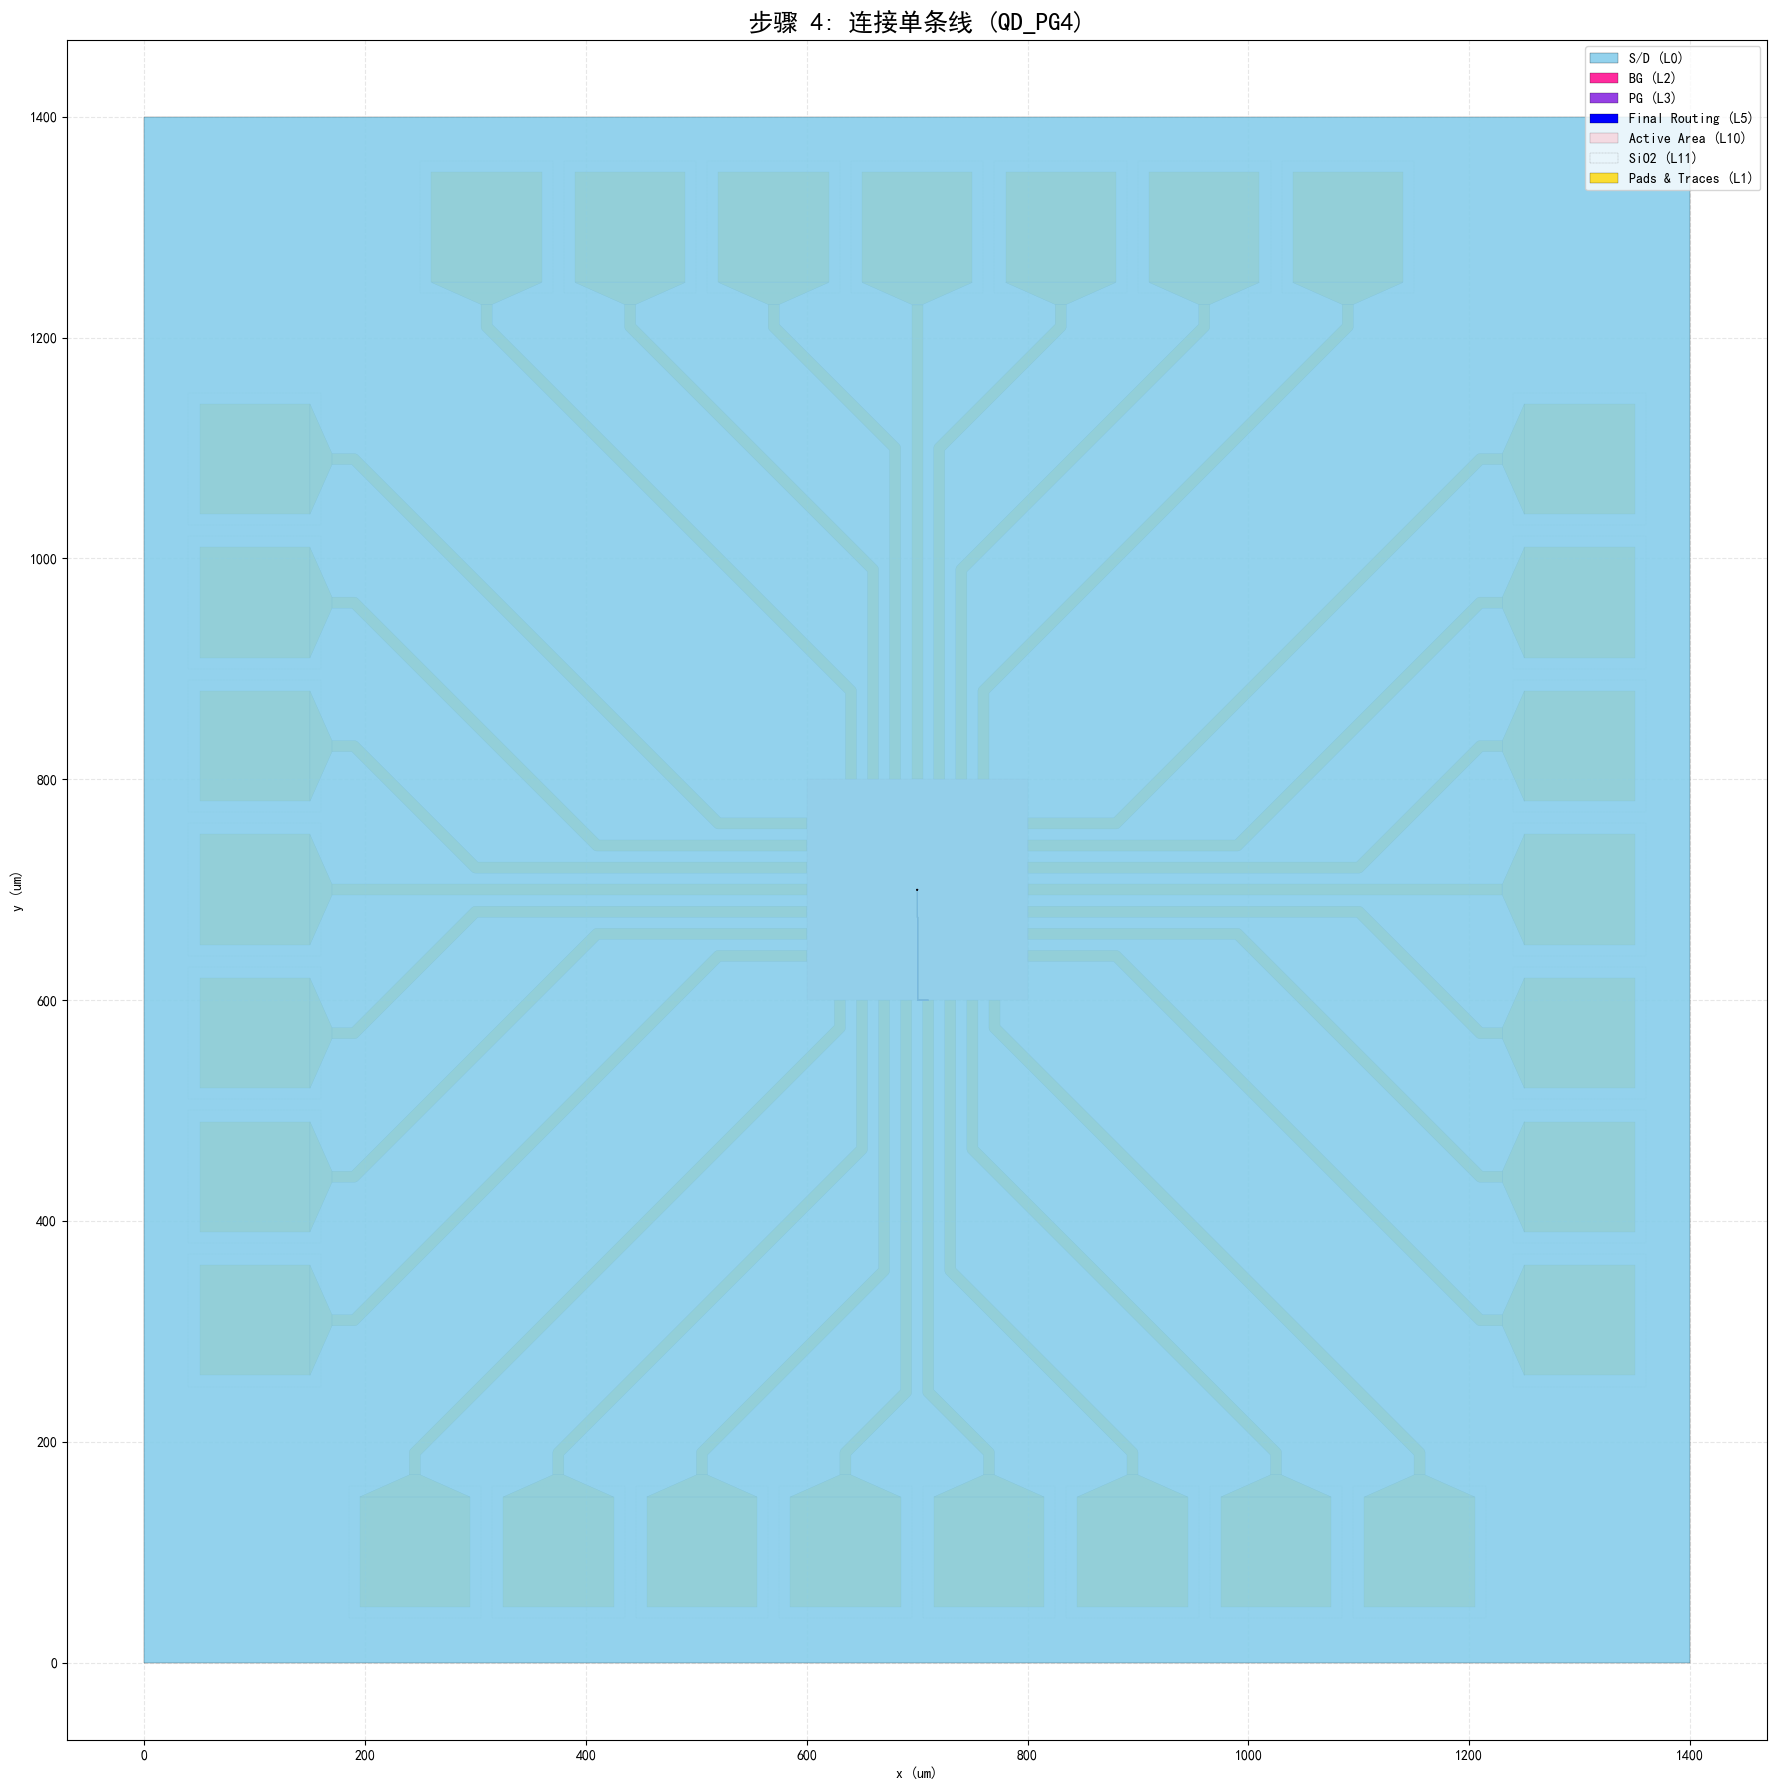

GDS 文件已保存到: 'step4_single_route.gds'

--- 步骤 5: 最终完整布线 ---
正在可视化: 步骤 5: 最终完整布线...


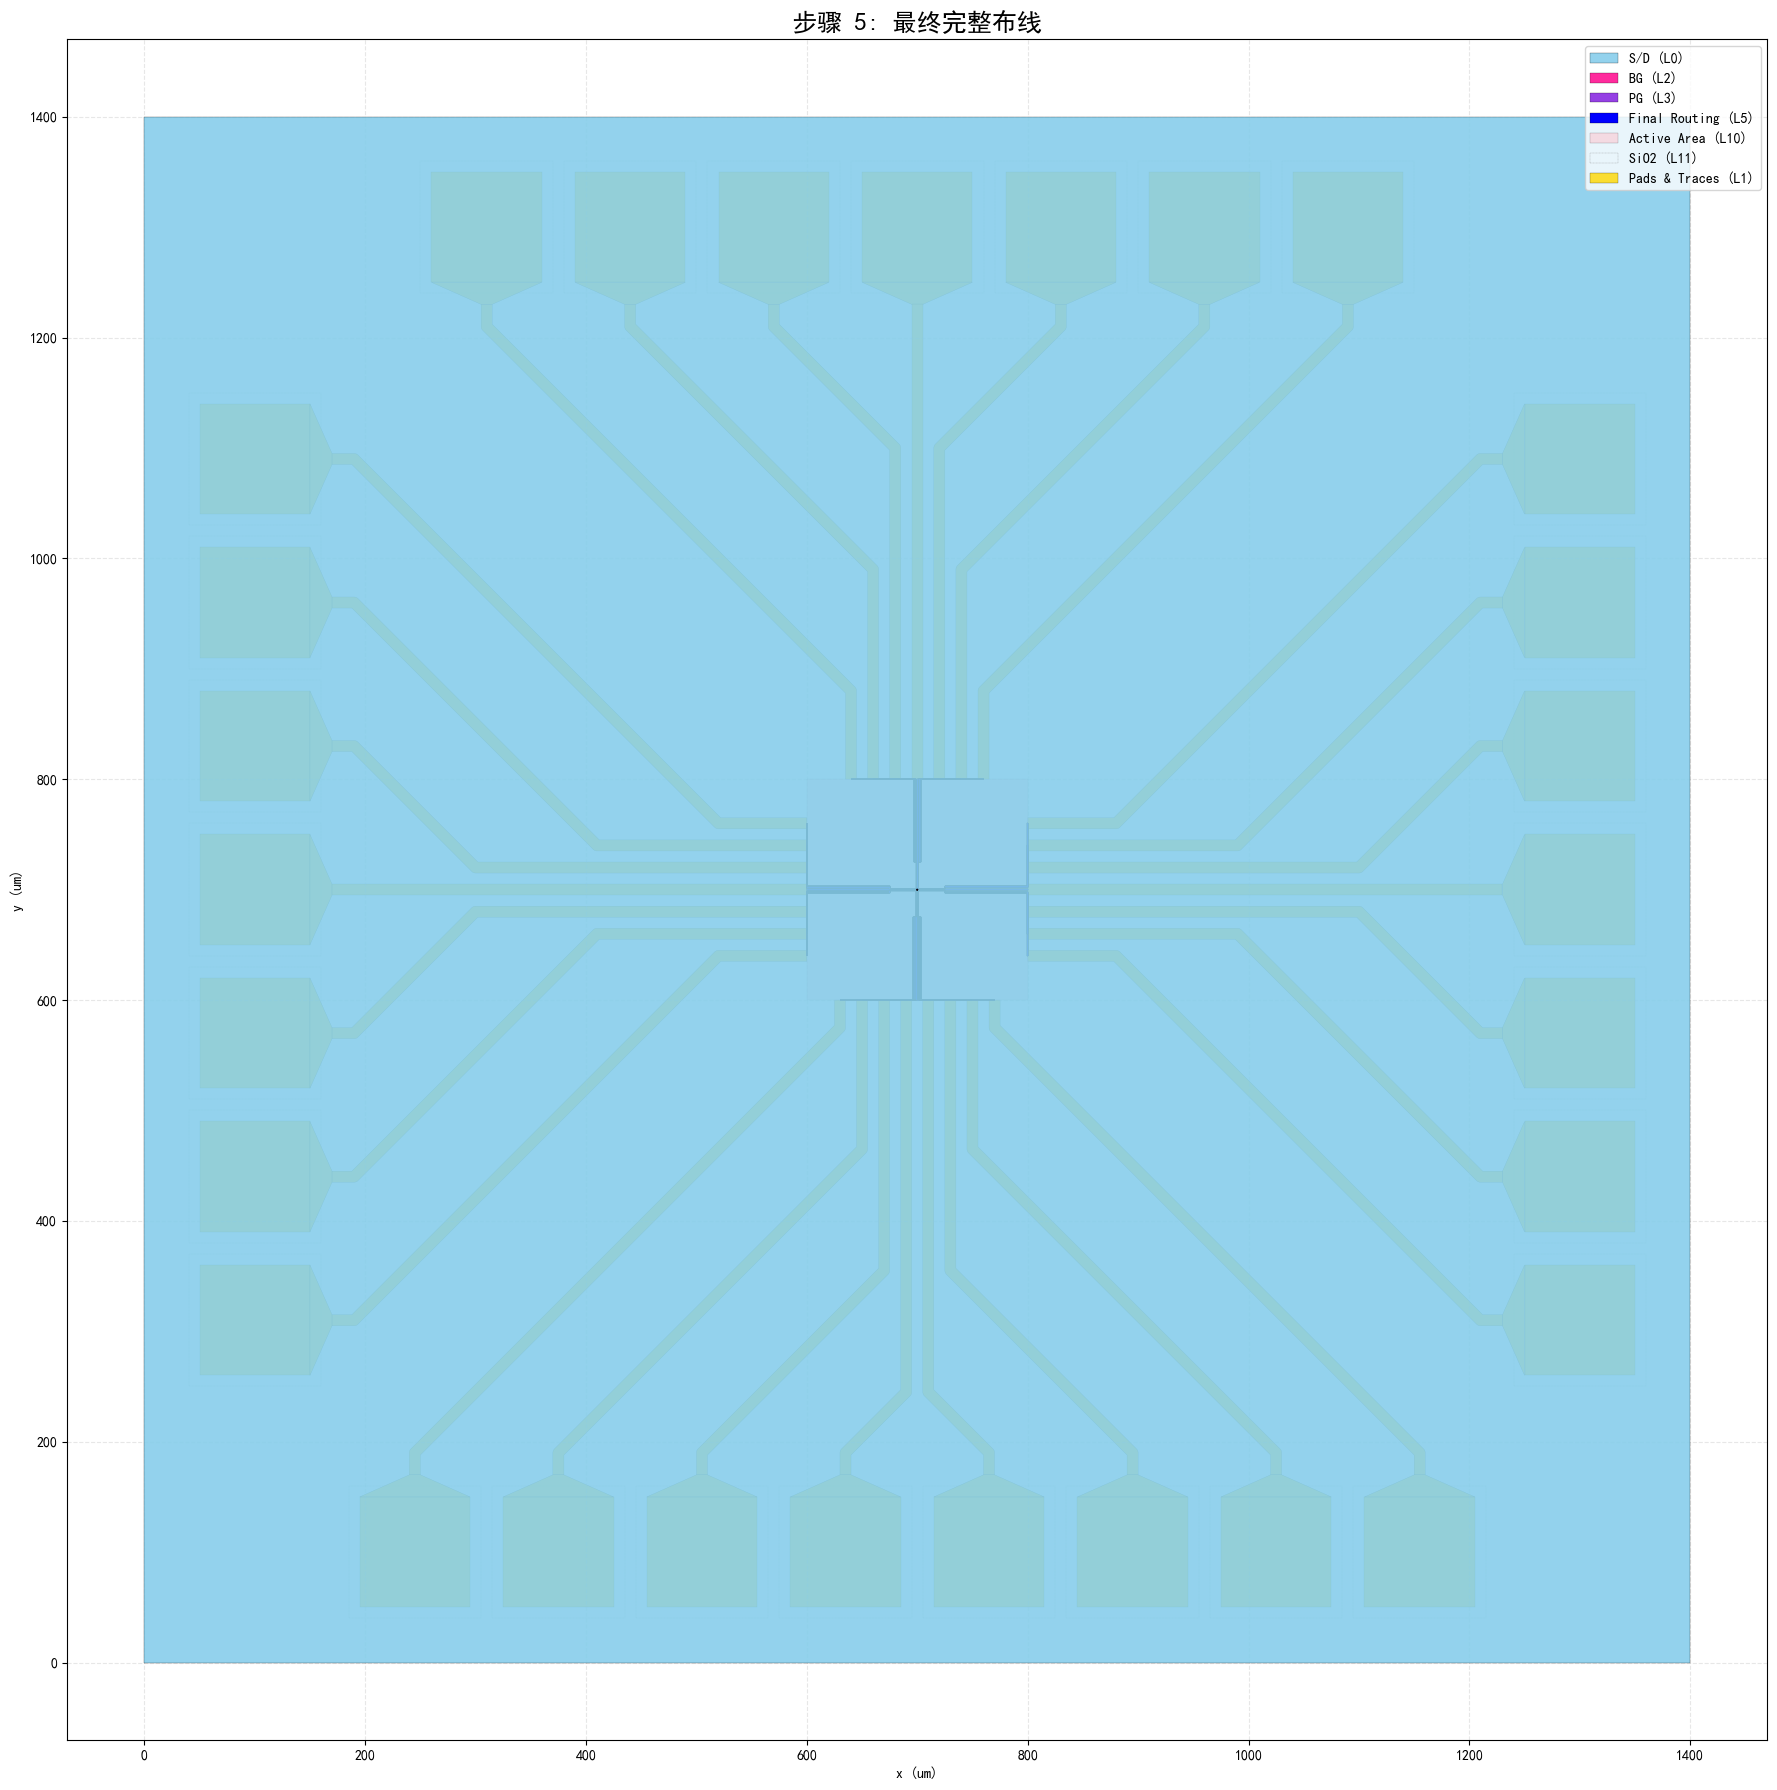

GDS 文件已保存到: 'step5_fully_routed.gds'

全部分步流程执行完毕！


In [1]:
import gdstk
import numpy as np

# 假设您的代码包文件名为 "my_layout_generators.py"
# 请根据您的实际文件名进行修改
%reload_ext autoreload
from QD_Layout_Gen_v3_20251215 import *

# ===================================================================
#                           主程序入口 (已更新)
# ===================================================================
if __name__ == "__main__":

    ACTIVE_SIZE = 200

    # --- 步骤 1: 生成并展示核心器件 ---
    lib_device, cell_device, device_points = create_6qd_layout_with_labels()
    plot_gds(cell_device, title="步骤 1: 仅带长引线的量子点器件")
    lib_device.write_gds("step1_device_with_leads.gds")

    # --- 步骤 2: 生成并展示焊盘框架 ---
    lib_pads, cell_pads, pad_points, active_center, all_pads_info = create_rect_wire_layout(active_size=ACTIVE_SIZE)
    visualize_and_save_pad_frame(lib_pads, cell_pads, "步骤 2: 仅带引线的焊盘框架", "step2_pad_frame.gds")

    # --- 创建一个查找表，用于快速获取每个标签的布线侧和索引 ---
    label_to_side_info = {}
    for pad_info in all_pads_info:
        label = pad_info['label']
        side = pad_info['edge']
        
        # 获取该侧的所有标签
        side_pads = [p for p in all_pads_info if p['edge'] == side]
        
        # 根据中心坐标对它们进行排序
        if side in ['top', 'bottom']:
            side_pads.sort(key=lambda p: p['center'][0])
        else: # left, right
            side_pads.sort(key=lambda p: p['center'][1], reverse=True)

        side_labels = [p['label'] for p in side_pads]

        if label in side_labels:
            index = side_labels.index(label)
            total = len(side_labels)
            label_to_side_info[label] = (side, index, total)

    # --- 步骤 3: 组装 ---
    bbox = cell_device.bounding_box();
    if bbox:
        (min_x,min_y),(max_x,max_y)=bbox; cx,cy=(min_x+max_x)/2,(min_y+max_y)/2
        for poly in cell_device.polygons: poly.translate(-cx,-cy)
        for label in cell_device.labels: label.origin=(label.origin[0]-cx,label.origin[1]-cy)
        for label,pos in device_points.items(): device_points[label]=(pos[0]-cx,pos[1]-cy)
    
    assembly_lib = gdstk.Library(); assembly_cell = assembly_lib.new_cell('ASSEMBLY_CELL')
    assembly_cell.add(gdstk.Reference(cell_pads))
    device_ref = gdstk.Reference(cell_device, active_center)
    assembly_cell.add(device_ref)
    
    visualize_and_save_assembly(assembly_lib, assembly_cell, "步骤 3: 器件已放置 (未布线)", "step3_placed_unrouted.gds")

    # --- 步骤 4 & 5: 使用全新 Fan-out 算法连接所有线 ---
    print("--- 步骤 4 & 5: 正在使用全新阶梯式 Fan-out 算法连接所有线... ---")
    ROUTING_LAYER = 5
    
    # 演示单条线
    label_to_connect = 'QD_PG4'
    if label_to_connect in device_points and label_to_connect in pad_points and label_to_connect in label_to_side_info:
        pad_coord = pad_points[label_to_connect]; local_dev_coord = device_points[label_to_connect]
        global_dev_coord = (local_dev_coord[0] + active_center[0], local_dev_coord[1] + active_center[1])
        side_info = label_to_side_info[label_to_connect]
        
        geometries = route_tiered_z_fanout(start_pt=global_dev_coord, end_pt=pad_coord, chip_center=active_center, side_info=side_info, layer=ROUTING_LAYER)
        assembly_cell.add(*geometries)

    visualize_and_save_assembly(assembly_lib, assembly_cell, f"步骤 4: 连接单条线 ({label_to_connect})", "step4_single_route.gds")

    # 连接所有剩余的线
    for label, local_dev_coord in device_points.items():
        if label != label_to_connect and label in pad_points and label in label_to_side_info:
            pad_coord = pad_points[label]; global_dev_coord = (local_dev_coord[0] + active_center[0], local_dev_coord[1] + active_center[1])
            side_info = label_to_side_info[label]
            geometries = route_tiered_z_fanout(start_pt=global_dev_coord, end_pt=pad_coord, chip_center=active_center, side_info=side_info, layer=ROUTING_LAYER)
            assembly_cell.add(*geometries)
            
    visualize_and_save_assembly(assembly_lib, assembly_cell, "步骤 5: 最终完整布线", "step5_fully_routed.gds")

    print("全部分步流程执行完毕！")